# 🗺️ Bandung AI Travel Agent — Recommendation Engine
## Notebook 01: Data Pipeline + Model Training

**Capstone Project · Telkom University · Program Studi Data Science**

Notebook ini membangun pipeline lengkap dari:
- Crawling data destinasi wisata Bandung via Overpass API (OpenStreetMap)
- Feature engineering & preprocessing
- Training Content-Based Filtering (CBF) menggunakan cosine similarity
- Training Multi-Agent Reinforcement Learning (RL) dengan simulated environment
- Route optimization menggunakan TSP nearest-neighbor heuristic
- Evaluasi dan export model

**Output:** `models/cbf_model.pkl`, `models/rl_agent.pkl`, `models/scaler.pkl`, `data/processed/destinations.csv`

**Estimasi waktu runtime:** 5–15 menit (tergantung kecepatan internet untuk crawling)


In [4]:
# ============================================================
# CELL 1 — Setup & Instalasi Dependencies
# ============================================================
# Auto-install: cek import; kalau ada yang missing, install otomatis sekali.
import importlib
import importlib.util
import subprocess
import sys

REQUIRED = {
    "requests": "requests",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing = [pkg for mod, pkg in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    print(f"📦 Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✅ Install selesai.")
else:
    print("✅ Semua dependency sudah terpasang.")

import os
import re
import sys
import json
import math
import time
import pickle
import random
import urllib.parse
import warnings
from pathlib import Path
from datetime import date
from collections import defaultdict, deque, Counter

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"✅ Random seed set: {RANDOM_SEED}")

# Pastikan working directory adalah ROOT proyek (bukan folder notebooks/)
if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"📂 CWD: {Path.cwd()}")

# Buat semua direktori yang dibutuhkan
for d in ["data/raw", "data/processed", "models", "notebooks"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("✅ Struktur folder berhasil dibuat")
print("📁 data/raw/        → hasil crawling mentah")
print("📁 data/processed/  → dataset bersih .csv")
print("📁 models/          → model .pkl tersimpan")


✅ Semua dependency sudah terpasang.
✅ Random seed set: 42
📂 CWD: /kaggle/working
✅ Struktur folder berhasil dibuat
📁 data/raw/        → hasil crawling mentah
📁 data/processed/  → dataset bersih .csv
📁 models/          → model .pkl tersimpan


## 📡 Fase 1: Data Collection — Overpass API (OpenStreetMap)

Menggunakan Overpass API untuk mengambil POI (Point of Interest) wisata Bandung.
Bounding box Bandung Raya: `-7.2500, 107.3500, -6.7500, 107.9000`

| OSM Tag | Kategori Proyek |
|---|---|
| `tourism=viewpoint`, `natural=*`, `leisure=park` | Alam |
| `amenity=restaurant`, `amenity=cafe`, `amenity=food_court` | Kuliner |
| `tourism=museum`, `historic=*`, `amenity=place_of_worship` | Budaya |
| `tourism=theme_park`, `tourism=attraction`, `leisure=*` | Wisata |
| `shop=mall`, `amenity=marketplace` | Belanja |


In [5]:
# ============================================================
# CELL 3 — Crawling Overpass API
# ============================================================
# Daftar mirror Overpass (urutan = prioritas). Kalau yang utama 406/429/5xx,
# fallback otomatis ke mirror berikutnya.
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass.openstreetmap.fr/api/interpreter",
]

# Overpass utama menolak default UA `python-requests/x.x` (HTTP 406).
# Header eksplisit ini wajib supaya request diterima semua mirror.
OVERPASS_HEADERS = {
    "User-Agent": (
        "Bandung-AI-Travel-Capstone/1.0 "
        "(Telkom University; "
        "+https://github.com/Fall-Llihc/Bandung_AI_Travel-Capstone-Project)"
    ),
    "Accept": "application/json",
    "Accept-Encoding": "gzip, deflate",
}

BANDUNG_BBOX = "-7.2500,107.3500,-6.7500,107.9000"  # south,west,north,east

OSM_CATEGORY_MAP = {
    # Alam
    "viewpoint": "Alam", "natural": "Alam", "park": "Alam",
    "waterfall": "Alam", "forest": "Alam",
    # Kuliner
    "restaurant": "Kuliner", "cafe": "Kuliner", "food_court": "Kuliner",
    "fast_food": "Kuliner",
    # Budaya
    "museum": "Budaya", "memorial": "Budaya", "artwork": "Budaya",
    "place_of_worship": "Budaya", "historic": "Budaya",
    # Wisata
    "theme_park": "Wisata", "attraction": "Wisata", "zoo": "Wisata",
    "aquarium": "Wisata", "amusement_ride": "Wisata",
    # Belanja
    "mall": "Belanja", "marketplace": "Belanja", "department_store": "Belanja",
}

# Query template per kategori (kombinasi nodes & ways yang relevan)
CATEGORY_QUERIES = {
    "Alam": """
        node["tourism"="viewpoint"]({bbox});
        node["natural"="peak"]({bbox});
        node["natural"="waterfall"]({bbox});
        way["leisure"="park"]({bbox});
        way["natural"="wood"]({bbox});
    """,
    "Kuliner": """
        node["amenity"="restaurant"]({bbox});
        node["amenity"="cafe"]({bbox});
        node["amenity"="food_court"]({bbox});
        node["amenity"="fast_food"]({bbox});
    """,
    "Budaya": """
        node["tourism"="museum"]({bbox});
        node["historic"~"."]({bbox});
        node["amenity"="place_of_worship"]({bbox});
        node["tourism"="memorial"]({bbox});
        way["tourism"="museum"]({bbox});
    """,
    "Wisata": """
        node["tourism"="theme_park"]({bbox});
        node["tourism"="attraction"]({bbox});
        node["tourism"="zoo"]({bbox});
        way["tourism"="theme_park"]({bbox});
        way["leisure"="garden"]({bbox});
    """,
    "Belanja": """
        node["shop"="mall"]({bbox});
        node["amenity"="marketplace"]({bbox});
        way["shop"="mall"]({bbox});
        way["shop"="department_store"]({bbox});
    """,
}


def query_overpass(query_str: str, max_retries: int = 2) -> dict:
    """Kirim Overpass QL query, return parsed JSON (dict kosong jika gagal total).

    Strategi:
      1. Loop semua mirror di OVERPASS_ENDPOINTS.
      2. Per mirror, retry sampai `max_retries` kali untuk 429/5xx.
      3. Selalu kirim User-Agent + Accept (wajib agar tidak ditolak 406).
      4. Sleep singkat antar request supaya sopan ke server publik.
    """
    full_query = f"[out:json][timeout:30];({query_str});out center 60;"
    last_err = None
    for endpoint in OVERPASS_ENDPOINTS:
        host = endpoint.split("//", 1)[1].split("/", 1)[0]
        for attempt in range(max_retries):
            try:
                resp = requests.post(
                    endpoint,
                    data={"data": full_query},
                    headers=OVERPASS_HEADERS,
                    timeout=45,
                )
                # 429 = rate limited, 5xx = mirror sibuk → backoff & retry
                if resp.status_code == 429 or 500 <= resp.status_code < 600:
                    last_err = f"HTTP {resp.status_code} dari {host}"
                    time.sleep(3 + attempt * 2)
                    continue
                resp.raise_for_status()
                time.sleep(1)  # rate limiting
                return resp.json()
            except Exception as e:
                last_err = f"{host}: {e}"
                time.sleep(2)
        print(f"  ↪️  Mirror gagal ({host}) — coba mirror berikutnya…")
    print(f"  ⚠️  Overpass error (semua mirror): {last_err}")
    return {}


def build_overpass_query(category: str, bbox: str) -> str:
    template = CATEGORY_QUERIES.get(category, "")
    return template.format(bbox=bbox)


def generate_gmaps_url(name: str) -> str:
    query = urllib.parse.quote(f"{name}, Bandung")
    return f"https://www.google.com/maps/search/?api=1&query={query}"


def fetch_all_categories() -> pd.DataFrame:
    """Loop seluruh kategori dan gabungkan hasil crawling jadi satu DataFrame."""
    rows = []
    for cat in ["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"]:
        q = build_overpass_query(cat, BANDUNG_BBOX)
        data = query_overpass(q)
        elements = data.get("elements", [])
        n_before = len(rows)
        for el in elements:
            tags = el.get("tags", {}) or {}
            name = tags.get("name") or tags.get("name:id")
            if not name or len(str(name).strip()) < 3:
                continue
            # koordinat: nodes punya lat/lon langsung; ways pakai center
            lat = el.get("lat") or el.get("center", {}).get("lat")
            lon = el.get("lon") or el.get("center", {}).get("lon")
            if lat is None or lon is None:
                continue
            rows.append({
                "id": f"osm-{el.get('type','n')}-{el.get('id')}",
                "name": str(name).strip(),
                "category": cat,
                "lat": float(lat),
                "lng": float(lon),
                "source": "overpass",
            })
        print(f"  [{cat}] {len(rows) - n_before} record dari Overpass")
    df = pd.DataFrame(rows)
    return df


print("🌍 Mulai crawling Overpass API…")
try:
    df_osm = fetch_all_categories()
except Exception as e:
    print(f"  ⚠️  Crawling gagal total ({e}). Lanjut dengan dataset kosong.")
    df_osm = pd.DataFrame(columns=["id", "name", "category", "lat", "lng", "source"])

if len(df_osm):
    df_osm.to_csv("data/raw/osm_raw.csv", index=False)
    print(f"\n✅ {len(df_osm)} record tersimpan di data/raw/osm_raw.csv")
    print(df_osm.groupby("category").size())
    print("\n5 baris pertama:")
    print(df_osm.head())
else:
    print("ℹ️  Tidak ada data Overpass — pipeline akan tetap jalan dari seed + manual.")


🌍 Mulai crawling Overpass API…
  [Alam] 60 record dari Overpass
  [Kuliner] 59 record dari Overpass
  [Budaya] 47 record dari Overpass
  [Wisata] 54 record dari Overpass
  [Belanja] 58 record dari Overpass

✅ 278 record tersimpan di data/raw/osm_raw.csv
category
Alam       60
Belanja    58
Budaya     47
Kuliner    59
Wisata     54
dtype: int64

5 baris pertama:
                    id               name category       lat         lng  \
0   osm-node-546560517     Gunung Kendang     Alam -7.245263  107.708569   
1  osm-node-1070155133       Pasir Leutik     Alam -6.910556  107.872778   
2  osm-node-1070155210      Gunung Leutik     Alam -6.910556  107.521944   
3  osm-node-1070155328      Gunung Padang     Alam -7.052778  107.416389   
4  osm-node-1070155336  Gunung Cibatuipis     Alam -7.176500  107.760700   

     source  
0  overpass  
1  overpass  
2  overpass  
3  overpass  
4  overpass  


In [6]:
# ============================================================
# CELL 4 — Seed data (16 dari frontend) + tambahan manual
# ============================================================
SEED_DESTINATIONS = [
    # ===== ALAM (5) =====
    # Durasi alam: parkir+jalan ke spot (15-30'), eksplorasi/foto (60-120'), istirahat (15-30')
    {"id": "kawah-putih", "name": "Kawah Putih", "category": "Alam",
     "desc": "Danau kawah vulkanik dengan air berwarna putih kehijauan di ketinggian 2430 mdpl",
     "ticket": 81000, "duration": 150, "lat": -7.1660, "lng": 107.4019,
     "rating": 4.6, "tags": ["sunrise", "fotogenik", "dingin"],
     "stay_detail": "Parkir & jalan ke kawah 20', keliling kawah & foto 90', istirahat 20', kembali ke parkir 20'"},
    {"id": "kebun-teh-rancabali", "name": "Kebun Teh Rancabali", "category": "Alam",
     "desc": "Hamparan kebun teh hijau di Ciwidey dengan udara sejuk dan pemandangan luas",
     "ticket": 25000, "duration": 105, "lat": -7.1432, "lng": 107.4106,
     "rating": 4.5, "tags": ["hijau", "fotogenik", "sejuk"],
     "stay_detail": "Jalan ke area kebun 15', jalan-jalan & foto di perkebunan 60', duduk santai 30'"},
    {"id": "stone-garden-padalarang", "name": "Stone Garden Padalarang", "category": "Alam",
     "desc": "Taman batu purba dengan formasi karst unik di kawasan Citatah, Padalarang",
     "ticket": 15000, "duration": 105, "lat": -6.8323, "lng": 107.4709,
     "rating": 4.4, "tags": ["batu", "fotogenik", "karst"],
     "stay_detail": "Naik ke area batu 20', eksplorasi formasi & foto 60', istirahat 25'"},
    {"id": "tebing-keraton", "name": "Tebing Keraton", "category": "Alam",
     "desc": "Tebing dengan view hutan pinus Dago Pakar, populer untuk sunrise",
     "ticket": 15000, "duration": 120, "lat": -6.8359, "lng": 107.6630,
     "rating": 4.5, "tags": ["sunrise", "hiking", "tebing"],
     "stay_detail": "Hiking ke tebing 30', menikmati view & foto 45', duduk santai 25', turun kembali 20'"},
    {"id": "tangkuban-perahu", "name": "Tangkuban Perahu", "category": "Alam",
     "desc": "Gunung berapi aktif dengan kawah ratu yang ikonik di utara Bandung",
     "ticket": 30000, "duration": 135, "lat": -6.7597, "lng": 107.6098,
     "rating": 4.5, "tags": ["gunung", "kawah", "legendaris"],
     "stay_detail": "Parkir & jalan ke kawah ratu 20', lihat kawah & foto 45', jalan ke kawah domas 30', kembali 25', beli oleh-oleh 15'"},

    # ===== KULINER (3) =====
    # Durasi kuliner: antri (15-30'), pesan & tunggu (10-20'), makan (30-45'), santai (15-20')
    {"id": "floating-market-lembang", "name": "Floating Market Lembang", "category": "Kuliner",
     "desc": "Pasar terapung dengan beragam jajanan tradisional Sunda di atas perahu",
     "ticket": 30000, "duration": 105, "lat": -6.8121, "lng": 107.6178,
     "rating": 4.3, "tags": ["jajanan", "keluarga", "fotogenik"],
     "stay_detail": "Keliling pasar & pilih makanan 30', antri & beli jajanan 20', makan di perahu 35', foto-foto 20'"},
    {"id": "jalan-braga", "name": "Jalan Braga", "category": "Kuliner",
     "desc": "Kawasan bersejarah dengan kafe, resto, dan bangunan kolonial khas Bandung tempo dulu",
     "ticket": 0, "duration": 100, "lat": -6.9160, "lng": 107.6094,
     "rating": 4.4, "tags": ["heritage", "kafe", "malam"],
     "stay_detail": "Jalan-jalan sepanjang Braga 25', pilih & masuk kafe 10', pesan & tunggu 15', makan/ngopi 35', foto arsitektur 15'"},
    {"id": "punclut-bukit-bintang", "name": "Punclut Bukit Bintang", "category": "Kuliner",
     "desc": "Spot makan dengan view kota Bandung dari ketinggian, populer untuk dinner romantis",
     "ticket": 0, "duration": 110, "lat": -6.8528, "lng": 107.6235,
     "rating": 4.3, "tags": ["view", "romantis", "malam"],
     "stay_detail": "Cari tempat duduk & pesan 15', tunggu makanan 20', makan sambil nikmati view 45', foto & santai 30'"},

    # ===== BUDAYA (3) =====
    # Durasi budaya: antri tiket (10-15'), tur/keliling (45-90'), baca informasi/interaksi (15-30')
    {"id": "saung-angklung-udjo", "name": "Saung Angklung Udjo", "category": "Budaya",
     "desc": "Pusat pertunjukan dan pelatihan angklung — warisan budaya Sunda dunia",
     "ticket": 75000, "duration": 120, "lat": -6.8924, "lng": 107.6537,
     "rating": 4.7, "tags": ["pertunjukan", "edukasi", "tradisi"],
     "stay_detail": "Registrasi & duduk 15', pertunjukan angklung 60', workshop interaktif 30', beli merchandise 15'"},
    {"id": "gedung-sate", "name": "Gedung Sate", "category": "Budaya",
     "desc": "Gedung pemerintahan ikonik dengan arsitektur Indo-Eropa dan ornamen tusuk sate",
     "ticket": 5000, "duration": 75, "lat": -6.9024, "lng": 107.6188,
     "rating": 4.5, "tags": ["heritage", "ikon", "arsitektur"],
     "stay_detail": "Registrasi 10', tur dalam gedung & museum 40', foto eksterior & taman 25'"},
    {"id": "museum-geologi", "name": "Museum Geologi", "category": "Budaya",
     "desc": "Museum koleksi fosil, mineral, dan sejarah geologi nusantara",
     "ticket": 3000, "duration": 90, "lat": -6.9006, "lng": 107.6225,
     "rating": 4.5, "tags": ["edukasi", "fosil", "sains"],
     "stay_detail": "Beli tiket & antri 10', keliling lantai 1 (fosil) 30', keliling lantai 2 (mineral) 30', baca diorama & foto 20'"},

    # ===== WISATA (3) =====
    # Durasi wisata: antri tiket/masuk (15-20'), main/eksplorasi (60-180'), istirahat/makan (30-45')
    {"id": "farmhouse-lembang", "name": "Farmhouse Lembang", "category": "Wisata",
     "desc": "Wisata bertema Eropa dengan rumah hobbit, peternakan mini, dan susu segar",
     "ticket": 35000, "duration": 135, "lat": -6.8324, "lng": 107.6122,
     "rating": 4.3, "tags": ["keluarga", "fotogenik", "eropa"],
     "stay_detail": "Antri masuk 15', foto rumah hobbit & spot Eropa 40', petting zoo 25', minum susu & jajan 30', belanja souvenir 25'"},
    {"id": "dusun-bambu", "name": "Dusun Bambu", "category": "Wisata",
     "desc": "Resort & taman wisata keluarga bertema alam pegunungan dengan playground",
     "ticket": 25000, "duration": 150, "lat": -6.8005, "lng": 107.5701,
     "rating": 4.4, "tags": ["keluarga", "alam", "kuliner"],
     "stay_detail": "Masuk & jalan ke area utama 15', playground anak 40', makan di lutung kasarung 45', keliling danau & foto 30', istirahat 20'"},
    {"id": "trans-studio-bandung", "name": "Trans Studio Bandung", "category": "Wisata",
     "desc": "Theme park indoor terbesar di Indonesia dengan wahana berstandar internasional",
     "ticket": 280000, "duration": 270, "lat": -6.9273, "lng": 107.6364,
     "rating": 4.5, "tags": ["theme-park", "keluarga", "indoor"],
     "stay_detail": "Beli tiket & antri masuk 20', wahana utama (3-4 rides + antri) 150', pertunjukan 40', makan & istirahat 40', foto-foto 20'"},

    # ===== BELANJA (2) =====
    # Durasi belanja: parkir & masuk (10-15'), keliling toko (60-90'), coba/tawar (20-30'), bayar (10-15')
    {"id": "cihampelas-walk", "name": "Cihampelas Walk", "category": "Belanja",
     "desc": "Mall outdoor populer di Cihampelas, perpaduan factory outlet dan gaya hidup",
     "ticket": 0, "duration": 120, "lat": -6.8946, "lng": 107.6029,
     "rating": 4.3, "tags": ["mall", "kuliner", "fashion"],
     "stay_detail": "Parkir & masuk 10', keliling outlet fashion 50', coba baju & tawar 30', makan/ngopi di food court 30'"},
    {"id": "pasar-baru-trade-center", "name": "Pasar Baru Trade Center", "category": "Belanja",
     "desc": "Pusat grosir tekstil dan fashion legendaris di pusat kota Bandung",
     "ticket": 0, "duration": 120, "lat": -6.9166, "lng": 107.6075,
     "rating": 4.2, "tags": ["grosir", "fashion", "tradisional"],
     "stay_detail": "Parkir & masuk 10', keliling lantai tekstil 40', tawar-menawar 30', pilih & bayar 20', bawa ke mobil 20'"},
]

# ---------- Tambahan manual (≥34 destinasi) untuk total ≥50 ----------
EXTRA_DESTINATIONS = [
    # ALAM (8 tambahan)
    {"id": "situ-patenggang", "name": "Situ Patenggang", "category": "Alam",
     "desc": "Danau alami di Ciwidey dengan legenda Batu Cinta dan perahu wisata",
     "ticket": 30000, "duration": 135, "lat": -7.1769, "lng": 107.3656,
     "rating": 4.5, "tags": ["danau", "legenda", "perahu"],
     "stay_detail": "Beli tiket & jalan ke dermaga 15', naik perahu ke Batu Cinta 30', foto & keliling 45', kembali & istirahat 30', oleh-oleh 15'"},
    {"id": "curug-dago", "name": "Curug Dago", "category": "Alam",
     "desc": "Air terjun di kawasan Taman Hutan Raya Djuanda dengan jejak prasasti raja Thailand",
     "ticket": 17000, "duration": 105, "lat": -6.8540, "lng": 107.6299,
     "rating": 4.2, "tags": ["air-terjun", "hiking", "sejarah"],
     "stay_detail": "Hiking turun ke air terjun 25', nikmati & foto 30', lihat prasasti 15', naik kembali 25', istirahat 10'"},
    {"id": "curug-cimahi", "name": "Curug Cimahi", "category": "Alam",
     "desc": "Air terjun pelangi setinggi 87 meter di kawasan Cisarua",
     "ticket": 15000, "duration": 90, "lat": -6.8033, "lng": 107.5503,
     "rating": 4.4, "tags": ["air-terjun", "pelangi", "fotogenik"],
     "stay_detail": "Turun tangga ke viewpoint 20', menikmati view & foto 30', istirahat 15', naik kembali 25'"},
    {"id": "tahura-djuanda", "name": "Taman Hutan Raya Ir. H. Djuanda", "category": "Alam",
     "desc": "Hutan kota dengan goa Jepang, goa Belanda, dan trek alam di Dago Pakar",
     "ticket": 17000, "duration": 150, "lat": -6.8579, "lng": 107.6299,
     "rating": 4.5, "tags": ["hutan", "goa", "hiking"],
     "stay_detail": "Masuk & jalan ke goa Jepang 20', eksplorasi goa 25', trek ke goa Belanda 30', keliling taman 40', foto 20', kembali 15'"},
    {"id": "gunung-batu-lembang", "name": "Gunung Batu Lembang", "category": "Alam",
     "desc": "Bukit batu vulkanik kecil dengan view 360 derajat Lembang dan sekitarnya",
     "ticket": 10000, "duration": 105, "lat": -6.8208, "lng": 107.6238,
     "rating": 4.3, "tags": ["sunrise", "hiking", "view"],
     "stay_detail": "Persiapan & mulai hiking 10', naik ke puncak 30', foto & view 360° 30', turun 25', istirahat 10'"},
    {"id": "situ-lembang", "name": "Situ Lembang", "category": "Alam",
     "desc": "Danau yang dikelilingi hutan pinus, tenang dan asri di kawasan Lembang",
     "ticket": 10000, "duration": 90, "lat": -6.7880, "lng": 107.6063,
     "rating": 4.3, "tags": ["danau", "tenang", "alam"],
     "stay_detail": "Parkir & jalan ke danau 10', keliling danau & foto 40', santai di bawah pinus 30', kembali 10'"},
    {"id": "curug-malela", "name": "Curug Malela", "category": "Alam",
     "desc": "Air terjun bertingkat luas yang dijuluki Niagara mini-nya Bandung Barat",
     "ticket": 15000, "duration": 180, "lat": -6.9181, "lng": 107.3119,
     "rating": 4.5, "tags": ["air-terjun", "petualangan", "alam-liar"],
     "stay_detail": "Trek ke air terjun 40', nikmati & foto 45', main air 30', istirahat & makan bekal 25', trek kembali 40'"},
    {"id": "ranca-upas", "name": "Ranca Upas", "category": "Alam",
     "desc": "Bumi perkemahan dengan penangkaran rusa di tengah hutan pinus Ciwidey",
     "ticket": 25000, "duration": 135, "lat": -7.1432, "lng": 107.3779,
     "rating": 4.4, "tags": ["camping", "rusa", "hutan"],
     "stay_detail": "Masuk & jalan ke penangkaran 15', beri makan rusa 35', keliling hutan pinus 40', istirahat & jajan 30', kembali 15'"},

    # KULINER (7 tambahan)
    {"id": "warung-nasi-ampera", "name": "Warung Nasi Ampera", "category": "Kuliner",
     "desc": "Rumah makan Sunda legendaris dengan lalapan dan sambal khas",
     "ticket": 50000, "duration": 75, "lat": -6.9182, "lng": 107.6101,
     "rating": 4.3, "tags": ["sunda", "legendaris", "halal"],
     "stay_detail": "Antri & cari meja 15', pilih lauk & pesan 10', makan nasi Sunda 35', bayar 15'"},
    {"id": "mie-kocok-mang-dadeng", "name": "Mie Kocok Mang Dadeng", "category": "Kuliner",
     "desc": "Mie kocok khas Bandung dengan kuah kaldu sapi gurih sejak 1960-an",
     "ticket": 35000, "duration": 60, "lat": -6.9075, "lng": 107.6094,
     "rating": 4.5, "tags": ["mie", "khas-bandung", "legendaris"],
     "stay_detail": "Antri (bisa ramai) 15', pesan & tunggu masak 10', makan mie kocok 25', bayar 10'"},
    {"id": "kupat-tahu-gempol", "name": "Kupat Tahu Gempol", "category": "Kuliner",
     "desc": "Kupat tahu dengan bumbu kacang khas pasar Gempol, sarapan favorit warga",
     "ticket": 20000, "duration": 50, "lat": -6.9075, "lng": 107.6135,
     "rating": 4.4, "tags": ["sarapan", "tradisional", "murah"],
     "stay_detail": "Antri 10', pesan & tunggu 10', makan kupat tahu 20', bayar 10'"},
    {"id": "batagor-riri", "name": "Batagor Riri", "category": "Kuliner",
     "desc": "Batagor renyah dengan saus kacang manis-pedas khas Burangrang",
     "ticket": 25000, "duration": 50, "lat": -6.9223, "lng": 107.6116,
     "rating": 4.4, "tags": ["batagor", "khas-bandung", "jajanan"],
     "stay_detail": "Antri beli 10', tunggu goreng fresh 10', makan batagor 20', beli oleh-oleh 10'"},
    {"id": "warung-koffie-batavia", "name": "Warung Koffie Batavia", "category": "Kuliner",
     "desc": "Kafe bernuansa kolonial dengan aneka kopi nusantara di Jalan Braga",
     "ticket": 60000, "duration": 90, "lat": -6.9161, "lng": 107.6094,
     "rating": 4.4, "tags": ["kopi", "heritage", "kafe"],
     "stay_detail": "Masuk & pilih meja 10', pesan kopi & makanan 10', tunggu 15', ngopi santai 40', bayar 15'"},
    {"id": "sindang-reret", "name": "Restoran Sindang Reret", "category": "Kuliner",
     "desc": "Restoran Sunda dengan saung lesehan dan menu nasi liwet di Cikole",
     "ticket": 75000, "duration": 100, "lat": -6.7778, "lng": 107.6499,
     "rating": 4.3, "tags": ["sunda", "saung", "keluarga"],
     "stay_detail": "Cari saung & duduk 10', pesan 10', tunggu nasi liwet 20', makan bersama 40', foto & istirahat 20'"},
    {"id": "the-valley-bistro", "name": "The Valley Bistro Cafe", "category": "Kuliner",
     "desc": "Bistro berlokasi di lembah Dago dengan view dramatis kota Bandung",
     "ticket": 100000, "duration": 105, "lat": -6.8580, "lng": 107.6290,
     "rating": 4.4, "tags": ["bistro", "view", "romantis"],
     "stay_detail": "Reservasi/antri meja outdoor 15', pesan & tunggu 20', makan & nikmati view 45', foto 15', bayar 10'"},

    # BUDAYA (7 tambahan)
    {"id": "museum-konferensi-asia-afrika", "name": "Museum Konferensi Asia Afrika", "category": "Budaya",
     "desc": "Museum sejarah KAA 1955 di Gedung Merdeka, Jalan Asia Afrika",
     "ticket": 0, "duration": 90, "lat": -6.9211, "lng": 107.6098,
     "rating": 4.6, "tags": ["sejarah", "diplomasi", "gratis"],
     "stay_detail": "Registrasi 10', keliling ruang konferensi & diorama 40', baca panel sejarah 25', foto 15'"},
    {"id": "museum-sri-baduga", "name": "Museum Sri Baduga", "category": "Budaya",
     "desc": "Museum koleksi etnografi Sunda di kawasan Tegallega",
     "ticket": 5000, "duration": 90, "lat": -6.9367, "lng": 107.5996,
     "rating": 4.3, "tags": ["sunda", "edukasi", "etnografi"],
     "stay_detail": "Beli tiket 10', keliling koleksi etnografi 40', area keris & wayang 25', foto 15'"},
    {"id": "museum-pos-indonesia", "name": "Museum Pos Indonesia", "category": "Budaya",
     "desc": "Koleksi prangko, alat pos antik, dan sejarah perposan nasional",
     "ticket": 0, "duration": 60, "lat": -6.9018, "lng": 107.6193,
     "rating": 4.2, "tags": ["sejarah", "prangko", "gratis"],
     "stay_detail": "Masuk & registrasi 10', koleksi prangko & alat pos 30', ruang sejarah 15', foto 5'"},
    {"id": "monumen-perjuangan-jabar", "name": "Monumen Perjuangan Rakyat Jawa Barat", "category": "Budaya",
     "desc": "Monumen perjuangan dengan diorama sejarah di seberang Gasibu",
     "ticket": 5000, "duration": 75, "lat": -6.8924, "lng": 107.6207,
     "rating": 4.3, "tags": ["sejarah", "monumen", "edukasi"],
     "stay_detail": "Beli tiket 10', naik ke lantai diorama 15', lihat semua diorama 35', foto monumen 15'"},
    {"id": "taman-budaya-jawa-barat", "name": "Taman Budaya Jawa Barat", "category": "Budaya",
     "desc": "Pusat pertunjukan seni Sunda dengan amphitheater dan galeri",
     "ticket": 10000, "duration": 90, "lat": -6.8556, "lng": 107.6202,
     "rating": 4.2, "tags": ["pertunjukan", "seni", "sunda"],
     "stay_detail": "Masuk & lihat jadwal 10', keliling galeri seni 30', nonton pertunjukan 35', foto amphitheater 15'"},
    {"id": "vihara-vipassana-graha", "name": "Vihara Vipassana Graha", "category": "Budaya",
     "desc": "Vihara Buddhis dengan arsitektur khas dan taman meditasi di Lembang",
     "ticket": 0, "duration": 60, "lat": -6.7949, "lng": 107.6242,
     "rating": 4.5, "tags": ["religi", "tenang", "arsitektur"],
     "stay_detail": "Masuk & lepas sepatu 5', keliling vihara & taman 30', meditasi/duduk tenang 15', foto 10'"},
    {"id": "masjid-raya-bandung", "name": "Masjid Raya Bandung", "category": "Budaya",
     "desc": "Masjid agung kota Bandung dengan dua menara ikonik di Alun-Alun",
     "ticket": 0, "duration": 60, "lat": -6.9215, "lng": 107.6071,
     "rating": 4.7, "tags": ["religi", "ikon", "alun-alun"],
     "stay_detail": "Wudhu & persiapan 10', sholat/keliling interior 25', foto eksterior & menara 15', jalan di alun-alun 10'"},

    # WISATA (7 tambahan)
    {"id": "the-lodge-maribaya", "name": "The Lodge Maribaya", "category": "Wisata",
     "desc": "Spot foto ikonik dengan ayunan langit dan sky bridge di hutan pinus",
     "ticket": 50000, "duration": 135, "lat": -6.8154, "lng": 107.6593,
     "rating": 4.4, "tags": ["fotogenik", "ayunan", "hutan"],
     "stay_detail": "Antri masuk 15', antri & naik sky bridge 25', antri & foto ayunan 25', spot foto lain 35', jajan 20', kembali 15'"},
    {"id": "kampung-daun", "name": "Kampung Daun Culture Gallery", "category": "Wisata",
     "desc": "Resto-galeri bertema desa Sunda dengan saung di tengah hutan Cihideung",
     "ticket": 30000, "duration": 120, "lat": -6.8403, "lng": 107.5786,
     "rating": 4.5, "tags": ["sunda", "saung", "romantis"],
     "stay_detail": "Masuk & jalan ke saung 15', pesan makanan 10', tunggu masakan 20', makan di saung 40', keliling galeri 20', foto 15'"},
    {"id": "observatorium-bosscha", "name": "Observatorium Bosscha", "category": "Wisata",
     "desc": "Observatorium tertua di Indonesia dengan teleskop bersejarah di Lembang",
     "ticket": 20000, "duration": 105, "lat": -6.8244, "lng": 107.6166,
     "rating": 4.5, "tags": ["edukasi", "astronomi", "sejarah"],
     "stay_detail": "Registrasi & kumpul grup 15', presentasi astronomi 30', lihat teleskop 20', tanya jawab 15', foto & keliling 15', kembali 10'"},
    {"id": "kebun-binatang-bandung", "name": "Kebun Binatang Bandung", "category": "Wisata",
     "desc": "Kebun binatang klasik kota dengan koleksi satwa nusantara",
     "ticket": 50000, "duration": 165, "lat": -6.8919, "lng": 107.6067,
     "rating": 4.0, "tags": ["keluarga", "satwa", "edukasi"],
     "stay_detail": "Beli tiket & masuk 15', area mamalia 35', reptil & burung 30', primata 25', istirahat & makan 30', souvenir 15', kembali 15'"},
    {"id": "taman-film-bandung", "name": "Taman Film Bandung", "category": "Wisata",
     "desc": "Taman tematik di bawah jalan layang Pasupati dengan layar film outdoor",
     "ticket": 0, "duration": 60, "lat": -6.8959, "lng": 107.6125,
     "rating": 4.2, "tags": ["taman", "gratis", "kreatif"],
     "stay_detail": "Jalan masuk & cari spot 10', nonton film pendek 20', foto mural & instalasi 20', santai 10'"},
    {"id": "sky-lantern-lembang", "name": "Lembang Park & Zoo", "category": "Wisata",
     "desc": "Taman wisata dengan kebun binatang mini dan wahana keluarga di Lembang",
     "ticket": 50000, "duration": 150, "lat": -6.8137, "lng": 107.6172,
     "rating": 4.3, "tags": ["keluarga", "satwa", "wahana"],
     "stay_detail": "Antri masuk 15', kebun binatang mini 35', wahana anak 30', taman & foto 25', makan & istirahat 30', belanja 15'"},
    {"id": "orchid-forest-cikole", "name": "Orchid Forest Cikole", "category": "Wisata",
     "desc": "Taman hutan pinus dengan koleksi anggrek dan wood bridge fotogenik",
     "ticket": 50000, "duration": 120, "lat": -6.7796, "lng": 107.6531,
     "rating": 4.5, "tags": ["fotogenik", "anggrek", "hutan-pinus"],
     "stay_detail": "Masuk & jalan ke bridge 15', foto di wood bridge 20', kebun anggrek 30', hammock & hutan pinus 30', jajan 25'"},

    # BELANJA (7 tambahan)
    {"id": "btc-fashion-mall", "name": "BTC Fashion Mall", "category": "Belanja",
     "desc": "Mall fashion grosir di kawasan Pasteur dengan pilihan harga ekonomis",
     "ticket": 0, "duration": 105, "lat": -6.8917, "lng": 107.5745,
     "rating": 4.0, "tags": ["fashion", "grosir", "mall"],
     "stay_detail": "Parkir & masuk 10', keliling lantai fashion 40', coba & pilih baju 30', tawar & bayar 15', kembali 10'"},
    {"id": "rumah-mode", "name": "Outlet Rumah Mode", "category": "Belanja",
     "desc": "Factory outlet veteran di Setiabudhi dengan koleksi branded berdiskon",
     "ticket": 0, "duration": 105, "lat": -6.8601, "lng": 107.5926,
     "rating": 4.3, "tags": ["factory-outlet", "branded", "diskon"],
     "stay_detail": "Parkir & masuk 10', keliling rak branded 40', fitting room 25', antri kasir 20', kembali 10'"},
    {"id": "23-paskal", "name": "23 Paskal Shopping Center", "category": "Belanja",
     "desc": "Mall modern dekat stasiun dengan tenant fashion, kuliner, dan bioskop",
     "ticket": 0, "duration": 120, "lat": -6.9135, "lng": 107.5969,
     "rating": 4.4, "tags": ["mall", "modern", "kuliner"],
     "stay_detail": "Parkir & masuk 10', window shopping 30', belanja fashion 30', makan di food court 35', bayar parkir 15'"},
    {"id": "pasar-baru-lembang", "name": "Pasar Baru Lembang", "category": "Belanja",
     "desc": "Pasar tradisional Lembang dengan sayur, buah, dan oleh-oleh khas",
     "ticket": 0, "duration": 75, "lat": -6.8126, "lng": 107.6178,
     "rating": 4.2, "tags": ["pasar", "tradisional", "oleh-oleh"],
     "stay_detail": "Parkir & masuk pasar 10', keliling sayur & buah 20', beli oleh-oleh 25', tawar harga 10', kembali 10'"},
    {"id": "cibaduyut", "name": "Cibaduyut Shoes Center", "category": "Belanja",
     "desc": "Sentra produksi sepatu kulit handmade tertua di Indonesia",
     "ticket": 0, "duration": 105, "lat": -6.9624, "lng": 107.6021,
     "rating": 4.2, "tags": ["sepatu", "kulit", "handmade"],
     "stay_detail": "Parkir & jalan ke sentra 10', keliling toko sepatu 35', coba model 25', tawar & bayar 20', bungkus 15'"},
    {"id": "paris-van-java", "name": "Paris Van Java Mall", "category": "Belanja",
     "desc": "Mall lifestyle outdoor di Sukajadi dengan suasana al-fresco",
     "ticket": 0, "duration": 120, "lat": -6.8908, "lng": 107.5957,
     "rating": 4.5, "tags": ["mall", "outdoor", "lifestyle"],
     "stay_detail": "Parkir & masuk 10', jalan outdoor area 25', belanja tenant 35', ngopi di kafe 30', bayar parkir 10', kembali 10'"},
    {"id": "trans-studio-mall", "name": "Trans Studio Mall Bandung", "category": "Belanja",
     "desc": "Mall premium yang terhubung dengan Trans Studio theme park",
     "ticket": 0, "duration": 120, "lat": -6.9265, "lng": 107.6364,
     "rating": 4.5, "tags": ["mall", "premium", "kuliner"],
     "stay_detail": "Parkir & masuk 10', keliling tenant premium 35', belanja 30', makan di restoran 30', bayar parkir 15'"},
]

manual_df = pd.DataFrame(SEED_DESTINATIONS + EXTRA_DESTINATIONS)
manual_df["source"] = "manual"
print(f"📝 Seed: {len(SEED_DESTINATIONS)} | Extra: {len(EXTRA_DESTINATIONS)} | Total manual: {len(manual_df)}")

# ---------- Merge dengan hasil Overpass ----------
def slugify(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "-", str(name).lower()).strip("-")


def fuzzy_match(a: str, b: str) -> float:
    """Skor kesamaan berbasis token jaccard (0..1) — sederhana tapi cukup."""
    ta = set(re.findall(r"[a-z0-9]+", str(a).lower()))
    tb = set(re.findall(r"[a-z0-9]+", str(b).lower()))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)


def is_likely_duplicate(osm_name: str, seed_name: str) -> bool:
    """Lebih ketat dari fuzzy: substring atau jaccard >0.6."""
    a = re.sub(r"[^a-z0-9 ]+", " ", str(osm_name).lower()).strip()
    b = re.sub(r"[^a-z0-9 ]+", " ", str(seed_name).lower()).strip()
    if not a or not b:
        return False
    if a == b or a in b or b in a:
        return True
    return fuzzy_match(a, b) > 0.6


def merge_with_dedup(manual: pd.DataFrame, osm: pd.DataFrame) -> pd.DataFrame:
    """Merge manual (priority) + osm, drop duplikat (substring atau jaccard >0.6)."""
    if osm is None or len(osm) == 0:
        return manual.copy()
    manual_names = manual["name"].tolist()
    keep_rows = []
    for _, r in osm.iterrows():
        nm = r["name"]
        if any(is_likely_duplicate(nm, m) for m in manual_names):
            continue
        keep_rows.append(r)
    osm_unique = pd.DataFrame(keep_rows)
    return pd.concat([manual, osm_unique], ignore_index=True, sort=False)


df_enriched = merge_with_dedup(manual_df, df_osm if "df_osm" in dir() else pd.DataFrame())

# ---------- Pastikan SEMUA kolom yang dibutuhkan ada (defensive) ----------
EXPECTED_COLS = {
    "id": None, "name": None, "category": None,
    "desc": None, "ticket": None, "duration": None,
    "rating": None, "tags": None, "lat": None, "lng": None,
    "source": "osm" if not df_enriched.empty else "manual",
    "gmaps_url": None,
}
for col, default in EXPECTED_COLS.items():
    if col not in df_enriched.columns:
        df_enriched[col] = default

# ---------- Isi field default untuk record OSM ----------
df_enriched["id"] = df_enriched.apply(
    lambda r: r["id"] if pd.notna(r.get("id")) and str(r.get("id")).strip() else slugify(r["name"]),
    axis=1,
)
df_enriched["desc"] = df_enriched["desc"].fillna(
    df_enriched["category"].apply(lambda c: f"Destinasi wisata {c} di Bandung")
)
df_enriched["tags"] = df_enriched["tags"].apply(
    lambda x: x if isinstance(x, list) else []
)
df_enriched["gmaps_url"] = df_enriched["name"].apply(generate_gmaps_url)

# Drop duplikat id (jaga seed dulu)
df_enriched = df_enriched.drop_duplicates(subset=["id"], keep="first").reset_index(drop=True)

df_enriched.to_csv("data/raw/destinations_enriched.csv", index=False)
print(f"✅ {len(df_enriched)} destinasi tersimpan ke data/raw/destinations_enriched.csv")
print(df_enriched.groupby("category").size())


📝 Seed: 16 | Extra: 36 | Total manual: 52
✅ 316 destinasi tersimpan ke data/raw/destinations_enriched.csv
category
Alam       73
Belanja    62
Budaya     57
Kuliner    67
Wisata     57
dtype: int64


In [7]:
# ============================================================
# CELL 5 — Data Cleaning & Validation
# ============================================================
VALID_CATEGORIES = {"Alam", "Kuliner", "Budaya", "Wisata", "Belanja"}

# Default fallback jika semua nilai kategori NaN
DEFAULT_TICKET = {"Alam": 20000, "Kuliner": 35000, "Budaya": 10000, "Wisata": 50000, "Belanja": 0}
DEFAULT_DURATION = {"Alam": 120, "Kuliner": 75, "Budaya": 80, "Wisata": 135, "Belanja": 105}
DEFAULT_RATING = 4.2


def clean_destinations(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 0. Pastikan semua kolom wajib ada (idempotent)
    for col in ("id", "name", "category", "desc", "ticket", "duration",
                "rating", "tags", "lat", "lng", "gmaps_url", "stay_detail"):
        if col not in df.columns:
            df[col] = pd.NA

    # 1. Rename lon → lng (jika masih ada)
    if "lon" in df.columns and "lng" not in df.columns:
        df = df.rename(columns={"lon": "lng"})
    elif "lon" in df.columns and "lng" in df.columns:
        df["lng"] = df["lng"].fillna(df["lon"])
        df = df.drop(columns=["lon"])

    # 2. Filter kategori valid
    df = df[df["category"].isin(VALID_CATEGORIES)].copy()

    # 3. Fill missing — ticket, rating, duration per kategori
    for cat in VALID_CATEGORIES:
        mask = df["category"] == cat
        med_ticket = df.loc[mask, "ticket"].median()
        if pd.isna(med_ticket):
            med_ticket = DEFAULT_TICKET[cat]
        df.loc[mask, "ticket"] = df.loc[mask, "ticket"].fillna(med_ticket)

        mean_rating = df.loc[mask, "rating"].mean()
        if pd.isna(mean_rating):
            mean_rating = DEFAULT_RATING
        df.loc[mask, "rating"] = df.loc[mask, "rating"].fillna(mean_rating)

        med_dur = df.loc[mask, "duration"].median()
        if pd.isna(med_dur):
            med_dur = DEFAULT_DURATION[cat]
        df.loc[mask, "duration"] = df.loc[mask, "duration"].fillna(med_dur)

    df["desc"] = df["desc"].fillna(df["category"].apply(lambda c: f"Destinasi wisata {c} di Bandung"))
    df["tags"] = df["tags"].apply(lambda x: x if isinstance(x, list) else [])
    df["stay_detail"] = df["stay_detail"].fillna("")

    # 4. Type casting
    df["ticket"] = df["ticket"].astype(float).round().astype(int)
    df["duration"] = df["duration"].astype(float).round().astype(int)
    df["rating"] = df["rating"].astype(float).clip(1.0, 5.0)
    df["lat"] = df["lat"].astype(float)
    df["lng"] = df["lng"].astype(float)

    # 5. Validasi geografis & nama
    df = df[df["lat"].between(-7.4, -6.6)]
    df = df[df["lng"].between(107.2, 108.2)]
    df = df[df["name"].notna() & (df["name"].astype(str).str.len() >= 3)]

    # 6. Generate slug id jika kosong
    df["id"] = df.apply(
        lambda r: r["id"] if pd.notna(r["id"]) and str(r["id"]).strip() else slugify(r["name"]),
        axis=1,
    )

    # 7. Sort by category + rating desc
    df = df.sort_values(["category", "rating"], ascending=[True, False]).reset_index(drop=True)

    # 8. Pastikan gmaps_url ada
    if "gmaps_url" not in df.columns or df["gmaps_url"].isna().any():
        df["gmaps_url"] = df["gmaps_url"].fillna(df["name"].apply(generate_gmaps_url))

    return df


df_clean = clean_destinations(df_enriched)

# Assert minimal 50 destinasi & semua kategori
assert len(df_clean) >= 50, f"Dataset minimal 50 destinasi, dapat {len(df_clean)}"
assert set(df_clean["category"].unique()) == VALID_CATEGORIES, \
    f"Kategori tidak lengkap: {df_clean['category'].unique()}"

# Pastikan 16 seed destinations tetap ada
seed_ids = {d["id"] for d in SEED_DESTINATIONS}
present = seed_ids & set(df_clean["id"].tolist())
assert len(present) == len(seed_ids), f"Seed hilang: {seed_ids - present}"

print(f"✅ Dataset valid: {len(df_clean)} destinasi")
print("\nDistribusi per kategori:")
print(df_clean.groupby("category").size())

# Simpan
df_clean.to_csv("data/processed/destinations.csv", index=False)
with open("data/last_updated.txt", "w") as f:
    f.write(str(date.today()))

print("\n💾 data/processed/destinations.csv tersimpan")
print(f"💾 data/last_updated.txt = {date.today()}")
print("\nSample 5 destinasi teratas (rating tertinggi per kategori):")
print(df_clean.head().to_string(index=False))


✅ Dataset valid: 316 destinasi

Distribusi per kategori:
category
Alam       73
Belanja    62
Budaya     57
Kuliner    67
Wisata     57
dtype: int64

💾 data/processed/destinations.csv tersimpan
💾 data/last_updated.txt = 2026-05-23

Sample 5 destinasi teratas (rating tertinggi per kategori):
                 id                name category                                                                             desc  ticket  duration     lat      lng  rating                         tags                                                                                                                   stay_detail source                                                                            gmaps_url
        kawah-putih         Kawah Putih     Alam Danau kawah vulkanik dengan air berwarna putih kehijauan di ketinggian 2430 mdpl   81000       150 -7.1660 107.4019     4.6 [sunrise, fotogenik, dingin]                                  Parkir & jalan ke kawah 20', keliling kawah & foto 90

## ⚙️ Fase 2: Feature Engineering

Mengubah atribut destinasi menjadi vektor numerik untuk:
1. **CBF Model** — menghitung cosine similarity antar destinasi
2. **RL Agent** — representasi state/action sebagai vektor

| Fitur | Tipe | Keterangan |
|---|---|---|
| `category_*` | One-hot (5 kolom) | Alam, Kuliner, Budaya, Wisata, Belanja |
| `rating_norm` | float [0,1] | Rating dinormalisasi |
| `ticket_norm` | float [0,1] | Harga tiket dinormalisasi (log-scale) |
| `duration_norm` | float [0,1] | Durasi kunjungan dinormalisasi |
| `lat_norm`, `lng_norm` | float [0,1] | Koordinat dinormalisasi |
| `tags_tfidf_*` | float [0,1] (n kolom) | TF-IDF dari kolom tags |

Total dimensi: 5 (category) + 5 (numerik) + n_tfidf (tags) ≈ 20–30 dimensi.


In [8]:
# ============================================================
# CELL 7 — Feature Engineering
# ============================================================
df_feat = df_clean.copy()

# (a) One-hot encoding kategori (urutan tetap)
CATEGORY_ORDER = ["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"]
le_category = LabelEncoder()
le_category.fit(CATEGORY_ORDER)

category_onehot = np.zeros((len(df_feat), len(CATEGORY_ORDER)), dtype=float)
for i, cat in enumerate(df_feat["category"].tolist()):
    category_onehot[i, CATEGORY_ORDER.index(cat)] = 1.0

# (b) Normalisasi numerik (ticket → log-scale dulu)
df_feat["ticket_log"] = np.log1p(df_feat["ticket"].astype(float))

numeric_cols = ["ticket_log", "rating", "duration", "lat", "lng"]
scaler = MinMaxScaler()
numeric_normalized = scaler.fit_transform(df_feat[numeric_cols].values)

# (c) TF-IDF dari tags
df_feat["tags_str"] = df_feat["tags"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)
tfidf = TfidfVectorizer(max_features=20, min_df=1)
tfidf_matrix = tfidf.fit_transform(df_feat["tags_str"]).toarray()

# (c.1) MinMax normalize TF-IDF agar magnitude-nya sebanding dengan one-hot/numeric
# (raw TF-IDF L2-normalized → kolom kecil; ini meningkatkan kontribusi dim tags
#  pada cosine similarity tanpa mendominasi kolom kategori one-hot)
tfidf_scaler = MinMaxScaler()
if tfidf_matrix.shape[1] > 0 and tfidf_matrix.max() > 0:
    tfidf_matrix = tfidf_scaler.fit_transform(tfidf_matrix)
else:
    tfidf_scaler = None

# (d) Gabungkan
feature_matrix = np.hstack([category_onehot, numeric_normalized, tfidf_matrix])
print(f"✅ Feature matrix shape: {feature_matrix.shape}")
print(f"   - {category_onehot.shape[1]} kolom kategori")
print(f"   - {numeric_normalized.shape[1]} kolom numerik")
print(f"   - {tfidf_matrix.shape[1]} kolom TF-IDF")

# Simpan feature matrix
np.save("data/processed/feature_matrix.npy", feature_matrix)

# Simpan scaler & encoders
encoders = {
    "label_encoder_category": le_category,
    "scaler": scaler,
    "tfidf": tfidf,
    "tfidf_scaler": tfidf_scaler,
    "feature_cols": numeric_cols,
    "category_order": CATEGORY_ORDER,
    "n_category_dims": category_onehot.shape[1],
    "n_numeric_dims": numeric_normalized.shape[1],
    "n_tfidf_dims": tfidf_matrix.shape[1],
}
with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\n💾 data/processed/feature_matrix.npy")
print("💾 models/label_encoders.pkl")
print("💾 models/scaler.pkl")


✅ Feature matrix shape: (316, 30)
   - 5 kolom kategori
   - 5 kolom numerik
   - 20 kolom TF-IDF

💾 data/processed/feature_matrix.npy
💾 models/label_encoders.pkl
💾 models/scaler.pkl


## 🔍 Fase 3A: Content-Based Filtering (CBF)

CBF bekerja dengan menghitung **cosine similarity** antar vektor fitur destinasi.
Saat user memberikan preferensi, sistem:
1. Membangun **user profile vector** dari preferensi user
2. Menghitung cosine similarity antara user profile dan setiap destinasi
3. Mengembalikan destinasi dengan similarity tertinggi (setelah hard-constraint filter)

Formula:
```
similarity(user, dest) = (user_vec · dest_vec) / (||user_vec|| × ||dest_vec||)
```


In [9]:
# ============================================================
# CELL 9 — Training Content-Based Filtering
# ============================================================
def haversine_km(lat1, lng1, lat2, lng2) -> float:
    """Jarak Haversine (km) — modul global agar dipakai class lain."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lng2 - lng1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


class ContentBasedFilter:
    """Cosine-similarity recommender atas vektor fitur destinasi."""

    def __init__(self, feature_matrix: np.ndarray, destinations_df: pd.DataFrame, encoders: dict):
        self.feature_matrix = feature_matrix
        self.df = destinations_df.reset_index(drop=True)
        self.encoders = encoders
        self.similarity_matrix = None

    def fit(self):
        self.similarity_matrix = cosine_similarity(self.feature_matrix)
        print(f"✅ CBF fitted. Similarity matrix shape: {self.similarity_matrix.shape}")
        return self

    # ---- helpers ----
    def _category_dims(self) -> int:
        return self.encoders.get("n_category_dims", 5)

    def _numeric_start(self) -> int:
        return self._category_dims()

    def _numeric_end(self) -> int:
        return self._numeric_start() + self.encoders.get("n_numeric_dims", 5)

    def build_user_profile(self, categories: list, budget: float = None) -> np.ndarray:
        """Rata-rata fitur destinasi pada kategori user; budget di-override ke ticket dim."""
        if not categories:
            mask = np.ones(len(self.df), dtype=bool)
        else:
            mask = self.df["category"].isin(categories).values
        if mask.sum() == 0:
            mask = np.ones(len(self.df), dtype=bool)
        profile = self.feature_matrix[mask].mean(axis=0)

        # Override ticket_norm bila budget given.
        if budget is not None and budget > 0:
            scaler = self.encoders["scaler"]
            num_cols = self.encoders["feature_cols"]
            ticket_idx_in_numeric = num_cols.index("ticket_log")
            # Bangun row dummy dengan median per fitur supaya scaler stabil
            dummy = np.zeros((1, len(num_cols)))
            for j, col in enumerate(num_cols):
                if col == "ticket_log":
                    dummy[0, j] = math.log1p(budget)
                else:
                    dummy[0, j] = self.df[col if col != "ticket_log" else "ticket"].median() \
                        if col != "ticket_log" else math.log1p(self.df["ticket"].median())
            scaled = scaler.transform(dummy)[0]
            profile_idx = self._numeric_start() + ticket_idx_in_numeric
            profile[profile_idx] = scaled[ticket_idx_in_numeric]
        return profile.reshape(1, -1)

    def recommend(
        self,
        categories: list = None,
        budget: float = None,
        max_km: float = None,
        home_lat: float = None,
        home_lng: float = None,
        top_n: int = 20,
    ) -> pd.DataFrame:
        if self.similarity_matrix is None:
            self.fit()
        categories = categories or []
        user_profile = self.build_user_profile(categories, budget=budget)
        sims = cosine_similarity(user_profile, self.feature_matrix).flatten()

        out = self.df.copy()
        out["cbf_score"] = sims

        # Hard constraint: kategori
        if categories:
            mask = out["category"].isin(categories)
            if mask.sum() > 0:
                out = out[mask]
        # Budget: ticket <= budget
        if budget is not None:
            out_b = out[out["ticket"].astype(float) <= float(budget)]
            if len(out_b) > 0:
                out = out_b
        # Distance: haversine dari home <= max_km
        if max_km is not None and home_lat is not None and home_lng is not None:
            out = out.copy()
            out["dist_home_km"] = out.apply(
                lambda r: haversine_km(home_lat, home_lng, r["lat"], r["lng"]),
                axis=1,
            )
            within = out[out["dist_home_km"] <= float(max_km)]
            if len(within) > 0:
                out = within
        return out.sort_values("cbf_score", ascending=False).head(top_n).reset_index(drop=True)

    def get_similar_destinations(self, dest_id: str, top_n: int = 5) -> pd.DataFrame:
        if self.similarity_matrix is None:
            self.fit()
        idx_list = self.df.index[self.df["id"] == dest_id].tolist()
        if not idx_list:
            return self.df.head(0)
        idx = idx_list[0]
        sims = self.similarity_matrix[idx]
        order = np.argsort(-sims)
        order = [i for i in order if i != idx][:top_n]
        out = self.df.iloc[order].copy()
        out["sim_score"] = sims[order]
        return out.reset_index(drop=True)

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump({
                "similarity_matrix": self.similarity_matrix,
                "feature_matrix": self.feature_matrix,
                "df_index": self.df[["id", "name", "category"]].to_dict("records"),
            }, f)
        print(f"✅ CBF model disimpan ke {path}")

    @classmethod
    def load(cls, path: str, feature_matrix, destinations_df, encoders):
        with open(path, "rb") as f:
            data = pickle.load(f)
        obj = cls(feature_matrix, destinations_df, encoders)
        obj.similarity_matrix = data["similarity_matrix"]
        return obj


cbf_model = ContentBasedFilter(feature_matrix, df_clean, encoders).fit()

# ---- 3 quick tests ----
print("\n🧪 TEST 1 — Alam, budget 200k, top 5")
t1 = cbf_model.recommend(categories=["Alam"], budget=200000, top_n=5)
print(t1[["name", "category", "ticket", "rating", "cbf_score"]])

print("\n🧪 TEST 2 — Kuliner+Budaya, no budget, top 10")
t2 = cbf_model.recommend(categories=["Kuliner", "Budaya"], top_n=10)
print(t2[["name", "category", "ticket", "rating", "cbf_score"]])

print("\n🧪 TEST 3 — Wisata+Belanja, budget 500k, max 30km dari Alun-Alun, top 8")
t3 = cbf_model.recommend(
    categories=["Wisata", "Belanja"], budget=500000, max_km=30,
    home_lat=-6.9215, home_lng=107.6071, top_n=8,
)
cols = ["name", "category", "ticket", "rating", "cbf_score"]
if "dist_home_km" in t3.columns:
    cols.append("dist_home_km")
print(t3[cols])

# Simpan model
cbf_model.save("models/cbf_model.pkl")


✅ CBF fitted. Similarity matrix shape: (316, 316)

🧪 TEST 1 — Alam, budget 200k, top 5
                name category  ticket    rating  cbf_score
0    Gunung Bulangur     Alam   17000  4.430769   0.992757
1  Pasir Batukeupeul     Alam   17000  4.430769   0.991795
2         Gunung Aul     Alam   17000  4.430769   0.991313
3       Gunung Kerud     Alam   17000  4.430769   0.991121
4     Gunung Lagadar     Alam   17000  4.430769   0.990821

🧪 TEST 2 — Kuliner+Budaya, no budget, top 10
                       name category  ticket  rating  cbf_score
0          Bumi Sangkuriang  Kuliner   32500    4.37   0.920384
1        Rumah Makan Padang  Kuliner   32500    4.37   0.919342
2               Ayam Ayaman  Kuliner   32500    4.37   0.919325
3                  Mas Pras  Kuliner   32500    4.37   0.919219
4          dago panyawangan  Kuliner   32500    4.37   0.919171
5            Itenas Bandung  Kuliner   32500    4.37   0.919135
6  Warung Surabi Setiabudhi  Kuliner   32500    4.37   0.919041
7

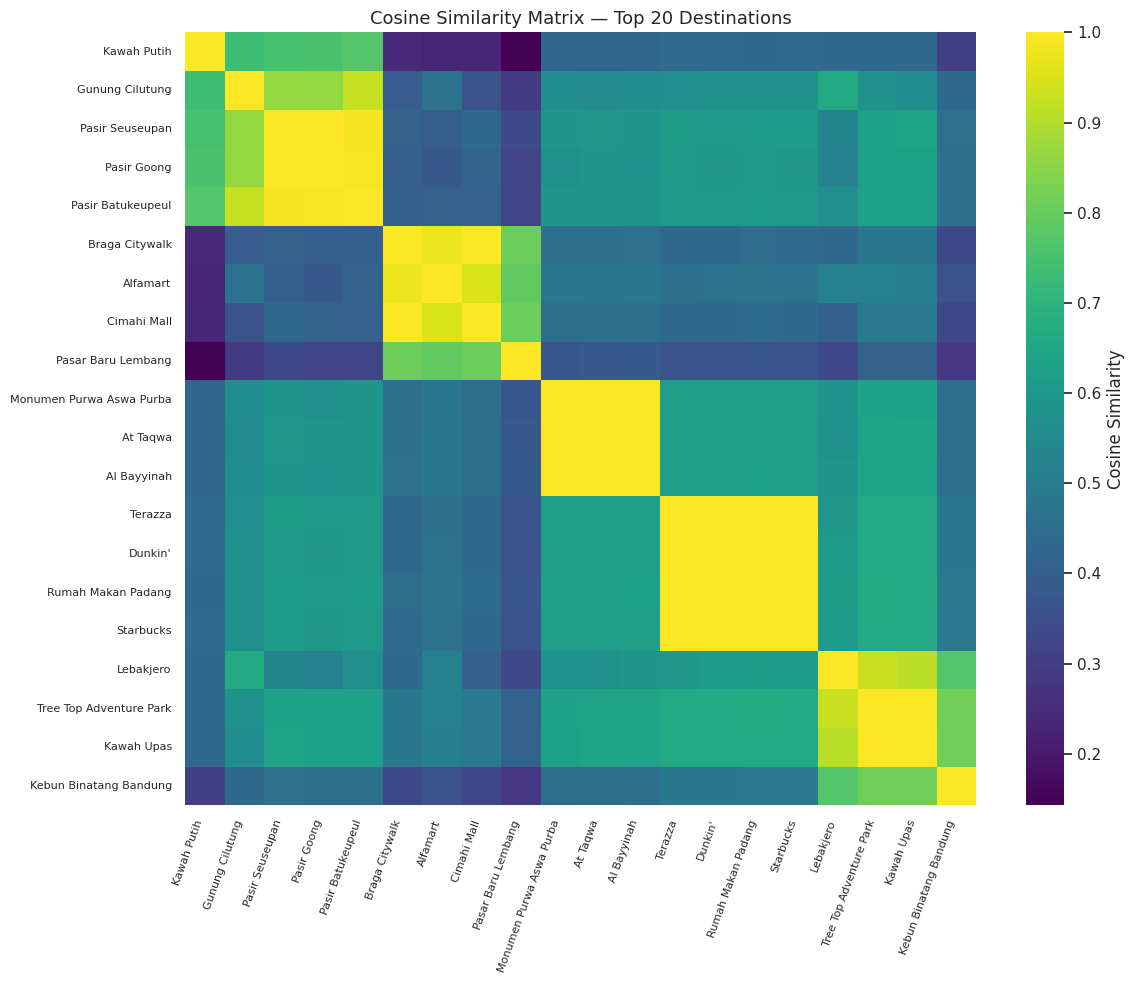


Menghitung average CBF score per kategori (sample 100 random user profiles)…


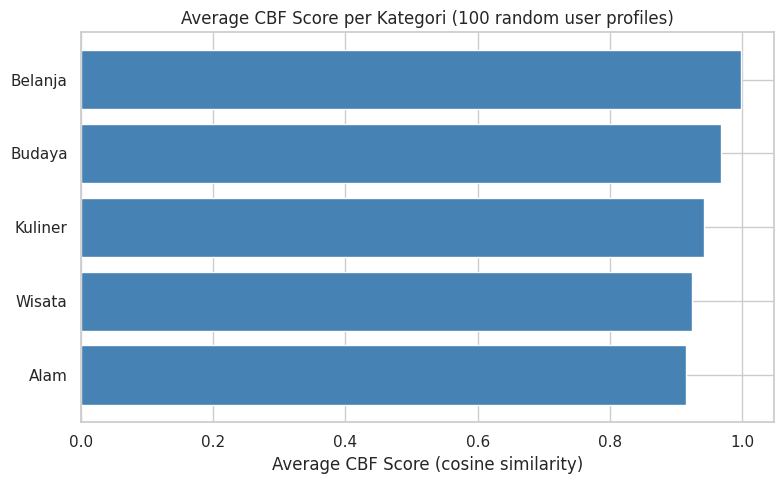

✅ data/processed/cbf_similarity_heatmap.png
✅ data/processed/cbf_category_scores.png


In [10]:
# ============================================================
# CELL 10 — Visualisasi CBF
# ============================================================
sns.set_theme(style="whitegrid")

# (a) Heatmap similarity matrix — subsample 20 destinasi
sample_n = min(20, len(df_clean))
sub_idx = np.linspace(0, len(df_clean) - 1, sample_n, dtype=int)
sub_sim = cbf_model.similarity_matrix[np.ix_(sub_idx, sub_idx)]
sub_names = df_clean.iloc[sub_idx]["name"].tolist()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sub_sim, xticklabels=sub_names, yticklabels=sub_names,
            cmap="viridis", ax=ax, cbar_kws={"label": "Cosine Similarity"})
ax.set_title("Cosine Similarity Matrix — Top 20 Destinations", fontsize=13)
plt.xticks(rotation=70, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("data/processed/cbf_similarity_heatmap.png", dpi=120)
plt.show()

# (b) Bar chart: rata-rata cbf_score per kategori
print("\nMenghitung average CBF score per kategori (sample 100 random user profiles)…")
score_per_cat = defaultdict(list)
for _ in range(100):
    cats = random.sample(["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"],
                        k=random.randint(1, 3))
    rec = cbf_model.recommend(categories=cats, top_n=10)
    if len(rec):
        for cat, sub in rec.groupby("category"):
            score_per_cat[cat].extend(sub["cbf_score"].tolist())

avg_scores = {k: float(np.mean(v)) for k, v in score_per_cat.items() if v}
fig, ax = plt.subplots(figsize=(8, 5))
cats_sorted = sorted(avg_scores, key=avg_scores.get)
ax.barh(cats_sorted, [avg_scores[c] for c in cats_sorted], color="steelblue")
ax.set_xlabel("Average CBF Score (cosine similarity)")
ax.set_title("Average CBF Score per Kategori (100 random user profiles)")
plt.tight_layout()
plt.savefig("data/processed/cbf_category_scores.png", dpi=120)
plt.show()

print("✅ data/processed/cbf_similarity_heatmap.png")
print("✅ data/processed/cbf_category_scores.png")


## 🤖 Fase 3B: Multi-Agent Reinforcement Learning

### Arsitektur

**Agent 1 — Filter Agent (rule-based, deterministik):** menghasilkan binary mask kandidat
yang lolos hard constraint (kategori, budget, jarak, waktu).

**Agent 2 — Selector Agent (Q-Learning tabular):** memilih destinasi berikutnya secara
sekuensial berdasarkan state diskret.

### Reward Function
```
R(s, a, s') = 0.5 * rating_score(a)        # rating / 5.0
            + 0.2 * variety_bonus(s, a)    # +0.2 jika kategori baru
            + 0.3 * budget_efficiency(s,a) # (budget - ticket) / budget
            - 1.0 * overtime_penalty
            - 0.5 * overbudget_penalty
```

### State Discretization (Q-table)
- `n_selected`: 0–8
- `budget_level`: 0 (habis) – 4 (>75% sisa)
- `time_level`: 0 – 4
- `dominant_cat`: indeks kategori dominan dari yang sudah dipilih

State space ≈ 9 × 5 × 5 × 5 = 1125 states.


In [11]:
# ============================================================
# CELL 12 — Training Q-Learning RL Agent
# ============================================================
HOME_OPTIONS = [
    {"lat": -6.9215, "lng": 107.6071, "name": "Alun-Alun Bandung"},
    {"lat": -6.9145, "lng": 107.6020, "name": "Stasiun Bandung"},
    {"lat": -6.8126, "lng": 107.6178, "name": "Pasar Lembang"},
    {"lat": -6.8915, "lng": 107.6107, "name": "Dago"},
    {"lat": -6.9024, "lng": 107.6188, "name": "Gedung Sate"},
]
SPEED_KMH = 28


class BandungTravelEnv:
    """Simulated env: user memilih destinasi satu per satu (sequential)."""

    REWARD_WEIGHTS = {"rating": 0.5, "variety": 0.2, "budget_eff": 0.3}
    PENALTY_OVERTIME = 1.0
    PENALTY_OVERBUDGET = 0.5

    def __init__(self, destinations_df: pd.DataFrame, cbf_model: ContentBasedFilter):
        self.df = destinations_df.reset_index(drop=True)
        self.cbf = cbf_model
        self.n_destinations = len(self.df)
        self.params = None
        self.candidates = []  # indeks pada self.df
        self.selected = []    # indeks pada self.df
        self.spent = 0
        self.cur_lat = None
        self.cur_lng = None
        self.cur_time = 0

    # ---- helpers ----
    def _haversine(self, lat1, lng1, lat2, lng2):
        return haversine_km(lat1, lng1, lat2, lng2)

    def _idx_by_id(self, dest_id: str) -> int:
        rows = self.df.index[self.df["id"] == dest_id].tolist()
        return rows[0] if rows else -1

    # ---- API ----
    def reset(self, params: dict):
        self.params = {**params}
        self.params.setdefault("budget", None)
        self.params.setdefault("max_km", None)
        if self.params["budget"] is None:
            self.params["budget"] = 999_999_999
        if self.params["max_km"] is None:
            self.params["max_km"] = 999
        self.params.setdefault("count", 4)
        self.params.setdefault("startMin", 9 * 60)
        self.params.setdefault("endMin", 21 * 60)
        self.params.setdefault("home_lat", HOME_OPTIONS[0]["lat"])
        self.params.setdefault("home_lng", HOME_OPTIONS[0]["lng"])

        # CBF top-30 jadi kandidat awal
        rec = self.cbf.recommend(
            categories=self.params.get("categories", []),
            budget=None if self.params["budget"] >= 999_999_998 else self.params["budget"],
            max_km=None if self.params["max_km"] >= 999 else self.params["max_km"],
            home_lat=self.params["home_lat"],
            home_lng=self.params["home_lng"],
            top_n=30,
        )
        if len(rec) == 0:
            rec = self.cbf.recommend(top_n=30)
        self.candidates = [self._idx_by_id(i) for i in rec["id"].tolist()]
        self.candidates = [i for i in self.candidates if i >= 0]

        self.selected = []
        self.spent = 0
        self.cur_lat = self.params["home_lat"]
        self.cur_lng = self.params["home_lng"]
        self.cur_time = self.params["startMin"]

        return self._get_state(), list(self.candidates)

    def _get_state(self):
        n_sel = min(8, len(self.selected))
        budget_total = self.params["budget"]
        # Bucket sesuai spec README:
        # 0 = habis, 1 = <25%, 2 = <50%, 3 = <75%, 4 = >=75% sisa
        if budget_total <= 0:
            budget_level = 0
        elif budget_total >= 999_999_998:
            # Effectively no budget limit
            budget_level = 4
        else:
            ratio = max(0.0, 1.0 - self.spent / budget_total)
            if ratio <= 0.0:
                budget_level = 0
            elif ratio < 0.25:
                budget_level = 1
            elif ratio < 0.50:
                budget_level = 2
            elif ratio < 0.75:
                budget_level = 3
            else:
                budget_level = 4
        time_left = max(0, self.params["endMin"] - self.cur_time)
        if time_left <= 0:
            time_level = 0
        elif time_left < 120:
            time_level = 1
        elif time_left < 240:
            time_level = 2
        elif time_left < 360:
            time_level = 3
        else:
            time_level = 4
        dom = 0
        if self.selected:
            cats = Counter(self.df.iloc[i]["category"] for i in self.selected)
            top_cat = cats.most_common(1)[0][0]
            order = ["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"]
            dom = order.index(top_cat) if top_cat in order else 0
        return (n_sel, budget_level, time_level, dom)

    def get_valid_actions(self):
        valid = []
        for k, idx in enumerate(self.candidates):
            if idx in self.selected:
                continue
            row = self.df.iloc[idx]
            if int(row["ticket"]) > (self.params["budget"] - self.spent):
                continue
            dist_home = self._haversine(
                self.params["home_lat"], self.params["home_lng"], row["lat"], row["lng"]
            )
            if dist_home > self.params["max_km"]:
                continue
            travel_km = self._haversine(self.cur_lat, self.cur_lng, row["lat"], row["lng"])
            travel_min = (travel_km / SPEED_KMH) * 60
            arrive = self.cur_time + travel_min
            depart = arrive + int(row["duration"])
            return_min = (self._haversine(
                row["lat"], row["lng"],
                self.params["home_lat"], self.params["home_lng"]
            ) / SPEED_KMH) * 60
            if depart + return_min > self.params["endMin"]:
                continue
            valid.append(k)
        return valid

    def _calculate_reward(self, dest_row, travel_km: float) -> float:
        rating_score = float(dest_row["rating"]) / 5.0
        # NOTE: dest_row sudah masuk ke self.selected & self.spent saat method ini dipanggil
        # (lihat step()), jadi cek variety harus exclude destinasi terakhir,
        # dan budget_eff tidak boleh mengurangi ticket lagi (sudah termasuk di self.spent).
        prior_selected = self.selected[:-1] if self.selected else []
        cats_chosen = {self.df.iloc[i]["category"] for i in prior_selected}
        variety = 0.2 if dest_row["category"] not in cats_chosen else 0.0

        budget_total = self.params["budget"]
        if budget_total <= 0 or budget_total >= 999_999_998:
            budget_eff = 0.5
        else:
            remain = max(0, budget_total - self.spent)  # spent already includes current ticket
            budget_eff = remain / budget_total

        w = self.REWARD_WEIGHTS
        r = w["rating"] * rating_score + w["variety"] * variety + w["budget_eff"] * budget_eff

        # Penalti
        if self.cur_time > self.params["endMin"]:
            r -= self.PENALTY_OVERTIME
        if self.spent > self.params["budget"]:
            r -= self.PENALTY_OVERBUDGET
        return float(r)

    def step(self, action_idx: int):
        valid = self.get_valid_actions()
        if action_idx not in valid:
            # Tidak valid → episode done dengan penalti kecil
            return self._get_state(), -0.1, True, {"reason": "invalid_action"}

        idx = self.candidates[action_idx]
        row = self.df.iloc[idx]
        travel_km = self._haversine(self.cur_lat, self.cur_lng, row["lat"], row["lng"])
        travel_min = (travel_km / SPEED_KMH) * 60
        self.cur_time += travel_min
        self.cur_time += int(row["duration"])
        self.spent += int(row["ticket"])
        self.selected.append(idx)
        self.cur_lat, self.cur_lng = row["lat"], row["lng"]

        reward = self._calculate_reward(row, travel_km)
        done = (
            len(self.selected) >= self.params["count"]
            or self.cur_time >= self.params["endMin"]
            or len(self.get_valid_actions()) == 0
        )
        return self._get_state(), reward, done, {"travel_km": travel_km}

    def generate_random_params(self) -> dict:
        cats_all = ["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"]
        n_cats = random.randint(1, len(cats_all))
        cats = random.sample(cats_all, k=n_cats)
        budget = None if random.random() < 0.20 else random.randint(50_000, 2_000_000)
        max_km = None if random.random() < 0.40 else random.randint(20, 80)
        count = random.randint(2, 6)
        start = random.randint(420, 600)
        end = start + random.randint(300, 900)
        home = random.choice(HOME_OPTIONS)
        return {
            "categories": cats,
            "budget": budget,
            "max_km": max_km,
            "count": count,
            "startMin": start,
            "endMin": end,
            "home_lat": home["lat"],
            "home_lng": home["lng"],
        }


class QLearningAgent:
    """Tabular Q-Learning dengan epsilon-greedy."""

    def __init__(self, learning_rate=0.1, discount_factor=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.training_history = []

    @staticmethod
    def _action_key(action_idx: int, candidate_ids: list) -> str:
        return candidate_ids[action_idx] if 0 <= action_idx < len(candidate_ids) else "unknown"

    def choose_action(self, state, valid_actions, candidate_ids):
        if not valid_actions:
            return -1
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        best, best_q = valid_actions[0], -float("inf")
        for a in valid_actions:
            q = self.q_table[state][self._action_key(a, candidate_ids)]
            if q > best_q:
                best_q, best = q, a
        return best

    def update(self, state, action_idx, reward, next_state, done,
               valid_next_actions, candidate_ids, next_candidate_ids):
        a_key = self._action_key(action_idx, candidate_ids)
        cur_q = self.q_table[state][a_key]
        if done or not valid_next_actions:
            target = reward
        else:
            future = max(
                self.q_table[next_state][self._action_key(a, next_candidate_ids)]
                for a in valid_next_actions
            )
            target = reward + self.gamma * future
        self.q_table[state][a_key] = cur_q + self.lr * (target - cur_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path: str):
        plain = {s: dict(actions) for s, actions in self.q_table.items()}
        data = {
            "q_table": plain,
            "epsilon": self.epsilon,
            "lr": self.lr,
            "gamma": self.gamma,
            "training_history": self.training_history,
        }
        with open(path, "wb") as f:
            pickle.dump(data, f)
        print(f"✅ RL Agent tersimpan ke {path}")

    @classmethod
    def load(cls, path: str):
        with open(path, "rb") as f:
            data = pickle.load(f)
        ag = cls(learning_rate=data["lr"], discount_factor=data["gamma"])
        ag.q_table = defaultdict(lambda: defaultdict(float))
        for s, actions in data["q_table"].items():
            for a, v in actions.items():
                ag.q_table[s][a] = v
        ag.epsilon = data["epsilon"]
        ag.training_history = data.get("training_history", [])
        return ag


def train_rl_agent(env: BandungTravelEnv, agent: QLearningAgent,
                   n_episodes: int = 3000, log_interval: int = 500) -> list:
    rewards_log = []
    for ep in tqdm(range(n_episodes), desc="Training RL Agent"):
        params = env.generate_random_params()
        state, candidates = env.reset(params)
        candidate_ids = [env.df.iloc[i]["id"] for i in candidates]
        total = 0.0
        done = False
        while not done:
            valid = env.get_valid_actions()
            if not valid:
                break
            action = agent.choose_action(state, valid, candidate_ids)
            if action < 0:
                break
            next_state, reward, done, _ = env.step(action)
            next_valid = env.get_valid_actions()
            agent.update(state, action, reward, next_state, done,
                         next_valid, candidate_ids, candidate_ids)
            state = next_state
            total += reward
        agent.decay_epsilon()
        rewards_log.append(total)
        agent.training_history.append(total)
        if (ep + 1) % log_interval == 0:
            avg = float(np.mean(rewards_log[-log_interval:]))
            print(f"  Episode {ep+1}/{n_episodes} | avg reward {avg:.4f} | ε {agent.epsilon:.3f}")
    return rewards_log


env = BandungTravelEnv(df_clean, cbf_model)
rl_agent = QLearningAgent()
N_EPISODES = 3000
rewards_log = train_rl_agent(env, rl_agent, n_episodes=N_EPISODES, log_interval=500)
rl_agent.save("models/rl_agent.pkl")


Training RL Agent:  17%|█▋        | 505/3000 [00:16<01:19, 31.56it/s]

  Episode 500/3000 | avg reward 2.3289 | ε 0.082


Training RL Agent:  34%|███▎      | 1006/3000 [00:31<00:59, 33.35it/s]

  Episode 1000/3000 | avg reward 2.2784 | ε 0.050


Training RL Agent:  50%|█████     | 1504/3000 [00:47<00:44, 33.51it/s]

...

  Episode 2000/3000 | avg reward 2.2431 | ε 0.050


Training RL Agent:  83%|████████▎ | 2504/3000 [01:18<00:15, 32.94it/s]

  Episode 2500/3000 | avg reward 2.3778 | ε 0.050


Training RL Agent: 100%|██████████| 3000/3000 [01:34<00:00, 31.80it/s]

  Episode 3000/3000 | avg reward 2.3902 | ε 0.050
✅ RL Agent tersimpan ke models/rl_agent.pkl


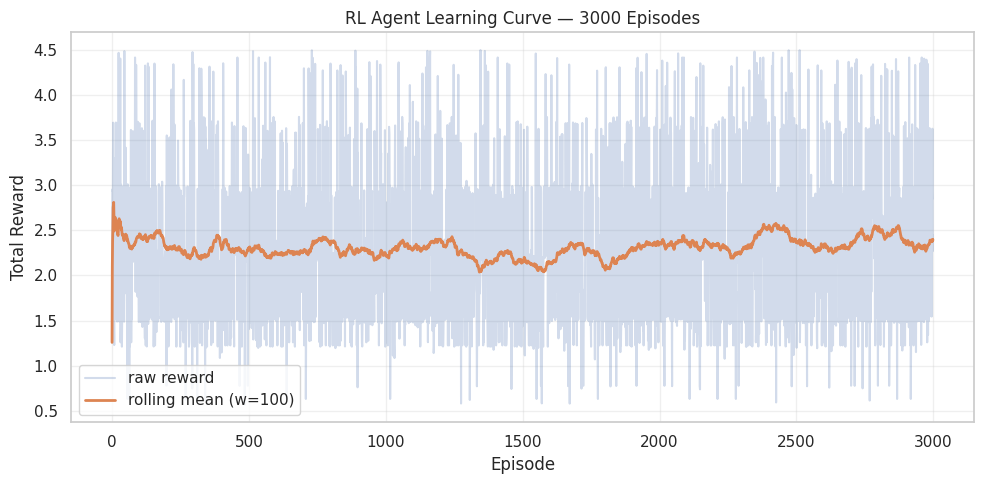

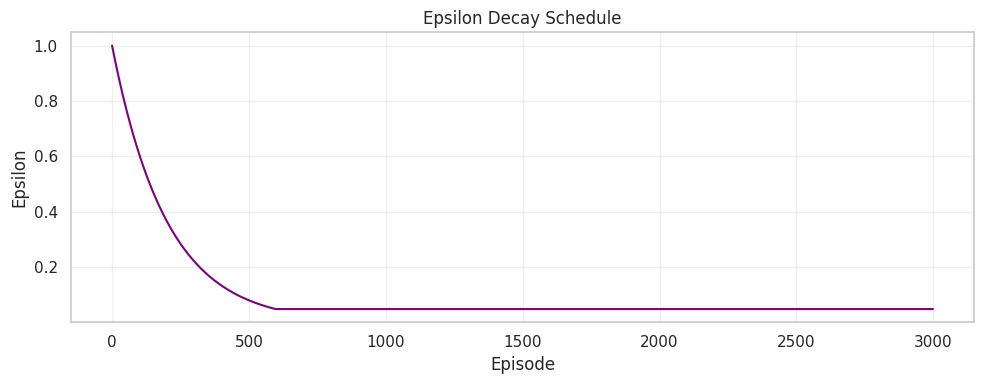

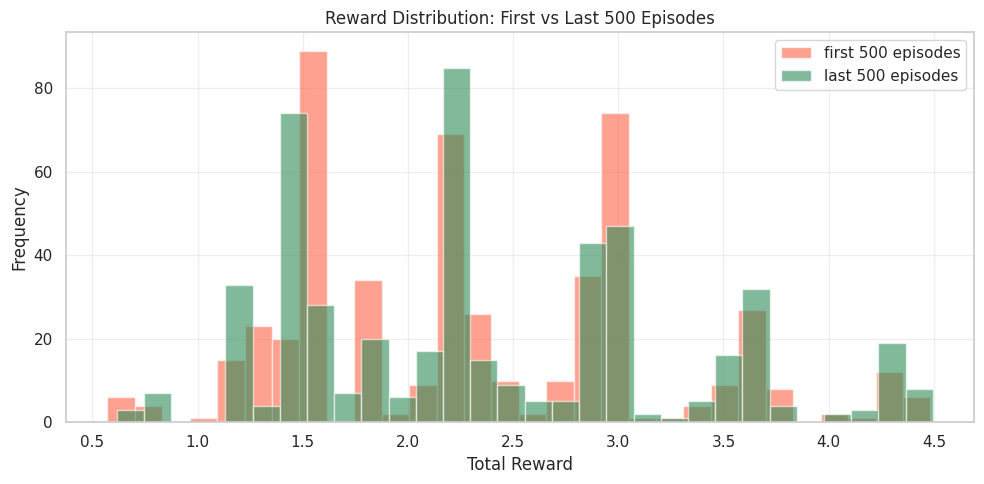

✅ Visualisasi tersimpan: rl_learning_curve.png, rl_epsilon_decay.png, rl_reward_distribution.png


In [12]:
# ============================================================
# CELL 13 — Visualisasi Training RL
# ============================================================
rewards_arr = np.array(rewards_log)
window = 100
rolling = pd.Series(rewards_arr).rolling(window=window, min_periods=1).mean().values

# (a) Learning curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rewards_arr, alpha=0.25, label="raw reward")
ax.plot(rolling, color="C1", linewidth=2, label=f"rolling mean (w={window})")
ax.set_xlabel("Episode"); ax.set_ylabel("Total Reward")
ax.set_title(f"RL Agent Learning Curve — {len(rewards_arr)} Episodes")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rl_learning_curve.png", dpi=120)
plt.show()

# (b) Epsilon decay (rekonstruksi)
ep_curve = []
eps = 1.0
for _ in range(len(rewards_arr)):
    ep_curve.append(eps)
    eps = max(rl_agent.epsilon_min, eps * rl_agent.epsilon_decay)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_curve, color="purple")
ax.set_xlabel("Episode"); ax.set_ylabel("Epsilon")
ax.set_title("Epsilon Decay Schedule")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rl_epsilon_decay.png", dpi=120)
plt.show()

# (c) Reward distribution awal vs akhir
first_chunk = rewards_arr[:500] if len(rewards_arr) >= 500 else rewards_arr[:len(rewards_arr)//2]
last_chunk = rewards_arr[-500:] if len(rewards_arr) >= 500 else rewards_arr[len(rewards_arr)//2:]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(first_chunk, bins=30, alpha=0.6, label="first 500 episodes", color="tomato")
ax.hist(last_chunk, bins=30, alpha=0.6, label="last 500 episodes", color="seagreen")
ax.set_xlabel("Total Reward"); ax.set_ylabel("Frequency")
ax.set_title("Reward Distribution: First vs Last 500 Episodes")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rl_reward_distribution.png", dpi=120)
plt.show()

print("✅ Visualisasi tersimpan: rl_learning_curve.png, rl_epsilon_decay.png, rl_reward_distribution.png")


## 🗺️ Fase 3C: Route Optimizer — TSP Nearest-Neighbor

Setelah RL Agent memilih N destinasi, urutan kunjungan dioptimalkan:
1. **Haversine Distance** untuk fallback offline
2. **OSRM API** (`router.project-osrm.org`) untuk waktu tempuh nyata bila tersedia
3. **Nearest-Neighbor Heuristic** untuk route ordering

OSRM endpoint:
```
GET http://router.project-osrm.org/route/v1/driving/{lng1},{lat1};{lng2},{lat2}?overview=false
```
Response → `routes[0].distance` (meter), `routes[0].duration` (detik).


In [13]:
# ============================================================
# CELL 15 — Route Optimizer (TSP Nearest-Neighbor + OSRM)
# ============================================================
class RouteOptimizer:
    SPEED_KMH = 28
    OSRM_BASE = "http://router.project-osrm.org/route/v1/driving"

    def __init__(self, use_osrm: bool = True, osrm_timeout: float = 5.0):
        self.use_osrm = use_osrm
        self.osrm_timeout = osrm_timeout
        # In-memory cache supaya panggilan ulang antar segment (mis. return trip
        # atau evaluasi 100x) tidak menghantam OSRM public berkali-kali.
        # Key: tuple koordinat dibulatkan ke 4 desimal (~11 m presisi).
        self._osrm_cache = {}

    def haversine_km(self, lat1, lng1, lat2, lng2) -> float:
        return haversine_km(lat1, lng1, lat2, lng2)

    def osrm_travel_time(self, lat1, lng1, lat2, lng2):
        """Return (distance_km, duration_min). Fallback ke Haversine bila OSRM gagal."""
        if not self.use_osrm:
            d = self.haversine_km(lat1, lng1, lat2, lng2)
            return d, (d / self.SPEED_KMH) * 60
        key = (round(lat1, 4), round(lng1, 4), round(lat2, 4), round(lng2, 4))
        if key in self._osrm_cache:
            return self._osrm_cache[key]
        try:
            url = f"{self.OSRM_BASE}/{lng1},{lat1};{lng2},{lat2}?overview=false"
            resp = requests.get(url, timeout=self.osrm_timeout)
            resp.raise_for_status()
            route = resp.json()["routes"][0]
            dist_km = route["distance"] / 1000.0
            dur_min = route["duration"] / 60.0
        except Exception:
            d = self.haversine_km(lat1, lng1, lat2, lng2)
            dist_km, dur_min = d, (d / self.SPEED_KMH) * 60
        self._osrm_cache[key] = (dist_km, dur_min)
        return dist_km, dur_min

    def nearest_neighbor_route(self, home: dict, destinations: list) -> list:
        if not destinations:
            return []
        remaining = list(destinations)
        ordered = []
        cur_lat, cur_lng = home["lat"], home["lng"]
        while remaining:
            nxt = min(remaining,
                      key=lambda d: self.haversine_km(cur_lat, cur_lng, d["lat"], d["lng"]))
            ordered.append(nxt)
            remaining = [d for d in remaining if d.get("id") != nxt.get("id")]
            cur_lat, cur_lng = nxt["lat"], nxt["lng"]
        return ordered

    def build_itinerary(self, home: dict, home_name: str, ordered_destinations: list,
                        start_min: int, end_min: int) -> dict:
        steps = []
        cur_lat, cur_lng = home["lat"], home["lng"]
        cur_time = start_min
        total_cost = 0
        total_km = 0.0
        total_visit_time = 0

        for i, dest in enumerate(ordered_destinations):
            travel_km, travel_min = self.osrm_travel_time(
                cur_lat, cur_lng, float(dest["lat"]), float(dest["lng"])
            )
            arrive = cur_time + int(round(travel_min))
            depart = arrive + int(dest.get("duration", 60))

            tags = dest.get("tags", [])
            if isinstance(tags, str):
                try:
                    tags = json.loads(tags.replace("'", '"'))
                except Exception:
                    tags = [t.strip() for t in tags.strip("[]").split(",") if t.strip()]

            steps.append({
                "idx": i + 1,
                "dest": {
                    "id": dest.get("id"),
                    "name": dest.get("name"),
                    "category": dest.get("category"),
                    "desc": dest.get("desc", ""),
                    "ticket": int(dest.get("ticket", 0)),
                    "duration": int(dest.get("duration", 60)),
                    "lat": float(dest["lat"]),
                    "lng": float(dest["lng"]),
                    "rating": float(dest.get("rating", 4.0)),
                    "tags": list(tags) if tags else [],
                    "gmaps_url": dest.get("gmaps_url") or generate_gmaps_url(dest.get("name", "")),
                    "stay_detail": dest.get("stay_detail", ""),
                },
                "travelMin": int(round(travel_min)),
                "travelKm": round(float(travel_km), 2),
                "arriveAt": int(arrive),
                "departAt": int(depart),
            })

            total_cost += int(dest.get("ticket", 0))
            total_km += float(travel_km)
            total_visit_time += int(dest.get("duration", 60))
            cur_lat, cur_lng = float(dest["lat"]), float(dest["lng"])
            cur_time = depart

        # return trip
        return_km, return_min = self.osrm_travel_time(cur_lat, cur_lng, home["lat"], home["lng"])
        arrive_home = cur_time + int(round(return_min))
        total_km += float(return_km)
        # totalTime = waktu total dari berangkat sampai tiba kembali (sesuai kontrak frontend)
        total_time = int(arrive_home - start_min)

        spare = end_min - arrive_home
        return {
            "steps": steps,
            "totalCost": int(total_cost),
            "totalKm": round(float(total_km), 2),
            "totalTime": int(total_time),
            "returnKm": round(float(return_km), 2),
            "returnMin": int(round(return_min)),
            "arriveHome": int(arrive_home),
            "overBudget": bool(arrive_home > end_min),  # alias "overTime" sesuai kontrak
            "spareMin": int(spare),
        }


optimizer = RouteOptimizer(use_osrm=True)

# Test cepat dengan 4 destinasi
sample = df_clean[df_clean["id"].isin([
    "kawah-putih", "saung-angklung-udjo", "gedung-sate", "cihampelas-walk"
])].to_dict("records")
home = {"lat": -6.9215, "lng": 107.6071}
ordered = optimizer.nearest_neighbor_route(home, sample)
itin = optimizer.build_itinerary(home, "Alun-Alun Bandung", ordered, 9 * 60, 21 * 60)

print("📍 Sample itinerary (4 destinasi):")
for s in itin["steps"]:
    a = f"{s['arriveAt']//60:02d}:{s['arriveAt']%60:02d}"
    d = f"{s['departAt']//60:02d}:{s['departAt']%60:02d}"
    print(f"  {s['idx']}. {s['dest']['name']:<28} | {a}-{d} | {s['travelKm']:.1f} km | stay {s['dest']['duration']} mnt")
    if s['dest'].get('stay_detail'):
        print(f"      ⏱️  {s['dest']['stay_detail']}")
print(f"\n💰 Total: Rp {itin['totalCost']:,} | 📏 {itin['totalKm']:.1f} km | 🏠 tiba {itin['arriveHome']//60:02d}:{itin['arriveHome']%60:02d}")


📍 Sample itinerary (4 destinasi):
  1. Gedung Sate                  | 09:06-10:21 | 4.5 km | stay 75 mnt
      ⏱️  Registrasi 10', tur dalam gedung & museum 40', foto eksterior & taman 25'
  2. Cihampelas Walk              | 10:27-12:27 | 4.9 km | stay 120 mnt
      ⏱️  Parkir & masuk 10', keliling outlet fashion 50', coba baju & tawar 30', makan/ngopi di food court 30'
  3. Saung Angklung Udjo          | 12:35-14:35 | 7.6 km | stay 120 mnt
      ⏱️  Registrasi & duduk 15', pertunjukan angklung 60', workshop interaktif 30', beli merchandise 15'
  4. Kawah Putih                  | 15:25-17:55 | 55.4 km | stay 150 mnt
      ⏱️  Parkir & jalan ke kawah 20', keliling kawah & foto 90', istirahat 20', kembali ke parkir 20'

💰 Total: Rp 161,000 | 📏 120.5 km | 🏠 tiba 18:38


In [14]:
# ============================================================
# CELL 16 — Integration Test (Full Pipeline) + Edge Cases
# ============================================================
def rl_select_destinations(env: BandungTravelEnv, agent: QLearningAgent,
                            params: dict) -> list:
    """Inference RL: greedy policy (epsilon=0). Tidak melakukan double-append —
    bergantung pada env.selected sebagai sumber kebenaran."""
    saved_eps = agent.epsilon
    agent.epsilon = 0.0
    try:
        state, candidates = env.reset(params)
        candidate_ids = [env.df.iloc[i]["id"] for i in candidates]
        done = False
        target = max(1, int(params.get("count", 4)))
        while not done and len(env.selected) < target:
            valid = env.get_valid_actions()
            if not valid:
                break
            action = agent.choose_action(state, valid, candidate_ids)
            if action < 0 or action >= len(env.candidates):
                break
            state, _, done, _ = env.step(action)
        # Pakai env.selected sebagai single source of truth
        return [env.df.iloc[i].to_dict() for i in env.selected]
    finally:
        agent.epsilon = saved_eps


def _smart_fallback_fill(selected: list, params: dict, target: int) -> list:
    """Lengkapi `selected` dengan kandidat CBF yang tetap menghormati
    sisa budget, sisa waktu, dan max_km dari home."""
    if len(selected) >= target:
        return selected
    home_lat = params["home"]["lat"]
    home_lng = params["home"]["lng"]
    spent = sum(int(d.get("ticket", 0)) for d in selected)
    used_dur = sum(int(d.get("duration", 0)) for d in selected)
    # Penting: budget=0 valid (artinya hanya gratis), bukan "no limit"
    has_budget = params.get("budget") is not None
    remaining_budget = (params["budget"] - spent) if has_budget else None
    remaining_time = max(0, params["endMin"] - params["startMin"] - used_dur)

    rec = cbf_model.recommend(
        categories=params.get("categories", []),
        budget=remaining_budget,
        max_km=params.get("maxKm"),
        home_lat=home_lat, home_lng=home_lng,
        top_n=30,
    )
    seen = {d["id"] for d in selected}
    for _, r in rec.iterrows():
        if len(selected) >= target:
            break
        if r["id"] in seen:
            continue
        if has_budget and int(r.get("ticket", 0)) > remaining_budget:
            continue
        if int(r.get("duration", 60)) > remaining_time:
            continue
        selected.append(r.to_dict())
        seen.add(r["id"])
        spent += int(r.get("ticket", 0))
        if has_budget:
            remaining_budget -= int(r.get("ticket", 0))
        remaining_time -= int(r.get("duration", 60))
    return selected


def full_pipeline_test(params: dict) -> dict:
    selected = rl_select_destinations(env, rl_agent, {
        "categories": params.get("categories", []),
        "budget": params.get("budget"),
        "max_km": params.get("maxKm"),
        "count": params.get("count", 4),
        "startMin": params["startMin"],
        "endMin": params["endMin"],
        "home_lat": params["home"]["lat"],
        "home_lng": params["home"]["lng"],
    })
    selected = _smart_fallback_fill(selected, params, params.get("count", 4))
    ordered = optimizer.nearest_neighbor_route(params["home"], selected)
    return optimizer.build_itinerary(
        home=params["home"],
        home_name=params["homeName"],
        ordered_destinations=ordered,
        start_min=params["startMin"],
        end_min=params["endMin"],
    )


def _print_itinerary(label: str, params: dict, res: dict):
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(f"Destinasi terpilih: {len(res['steps'])}")
    for s in res["steps"]:
        a = f"{s['arriveAt']//60:02d}:{s['arriveAt']%60:02d}"
        print(f"  {s['idx']}. {s['dest']['name']:<28} ({s['dest']['category']}) — tiba {a}")
    print(f"💰 Total biaya: Rp {res['totalCost']:,}")
    print(f"📏 Total jarak: {res['totalKm']:.1f} km | totalTime {res['totalTime']} mnt")
    print(f"🏠 Tiba kembali: {res['arriveHome']//60:02d}:{res['arriveHome']%60:02d} | overTime: {res['overBudget']}")


# ---------- 3 skenario utama ----------
test_cases = [
    {"home": {"lat": -6.9215, "lng": 107.6071}, "homeName": "Alun-Alun Bandung",
     "count": 4, "maxKm": None, "startMin": 9 * 60, "endMin": 21 * 60,
     "budget": 500_000, "categories": ["Alam", "Kuliner"]},
    {"home": {"lat": -6.8126, "lng": 107.6178}, "homeName": "Pasar Lembang",
     "count": 3, "maxKm": 25, "startMin": 8 * 60, "endMin": 18 * 60,
     "budget": 200_000, "categories": ["Alam"]},
    {"home": {"lat": -6.9145, "lng": 107.6020}, "homeName": "Stasiun Bandung",
     "count": 5, "maxKm": None, "startMin": 10 * 60, "endMin": 20 * 60,
     "budget": None, "categories": ["Kuliner", "Budaya", "Belanja"]},
]
main_results = []
for i, p in enumerate(test_cases, 1):
    res = full_pipeline_test(p)
    _print_itinerary(f"TEST CASE {i}: {p['homeName']}", p, res)
    main_results.append(res)


# ---------- Edge cases ----------
print("\n" + "#" * 60)
print("# EDGE CASES")
print("#" * 60)

edge_cases = [
    # Edge: budget = 0 → hanya destinasi gratis (ticket=0)
    {"label": "Edge 1 — budget = 0 (hanya gratis)",
     "params": {"home": {"lat": -6.9215, "lng": 107.6071}, "homeName": "Alun-Alun",
                "count": 3, "maxKm": None, "startMin": 9 * 60, "endMin": 17 * 60,
                "budget": 0, "categories": ["Budaya", "Belanja"]}},
    # Edge: count > kandidat tersedia (count=8 + max_km kecil)
    {"label": "Edge 2 — count > kandidat (max_km 5km, count=8)",
     "params": {"home": {"lat": -6.9215, "lng": 107.6071}, "homeName": "Alun-Alun",
                "count": 8, "maxKm": 5, "startMin": 8 * 60, "endMin": 22 * 60,
                "budget": None, "categories": ["Kuliner", "Budaya"]}},
    # Edge: semua kategori dipilih
    {"label": "Edge 3 — semua kategori",
     "params": {"home": {"lat": -6.9215, "lng": 107.6071}, "homeName": "Alun-Alun",
                "count": 5, "maxKm": None, "startMin": 8 * 60, "endMin": 21 * 60,
                "budget": 500_000,
                "categories": ["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"]}},
    # Edge: tidak ada kategori dipilih (frontend kadang kirim list kosong)
    {"label": "Edge 4 — tidak ada kategori (categories=[])",
     "params": {"home": {"lat": -6.9215, "lng": 107.6071}, "homeName": "Alun-Alun",
                "count": 3, "maxKm": None, "startMin": 9 * 60, "endMin": 19 * 60,
                "budget": 300_000, "categories": []}},
]
for ec in edge_cases:
    try:
        res = full_pipeline_test(ec["params"])
        _print_itinerary(ec["label"], ec["params"], res)
        # Validasi soft: minimal 1 destinasi terambil (kecuali jika benar-benar mustahil)
        if len(res["steps"]) == 0:
            print("  ℹ️  0 destinasi — kondisi memang mustahil, fallback kosong.")
    except Exception as e:
        print(f"  ❌ {ec['label']} crashed: {e}")



TEST CASE 1: Alun-Alun Bandung
Destinasi terpilih: 4
  1. Mambo FoodCourt              (Kuliner) — tiba 09:07
  2. Pizza Place                  (Kuliner) — tiba 10:43
  3. Dago Panineungan             (Kuliner) — tiba 12:20
  4. Gunung Buluh                 (Alam) — tiba 14:21
💰 Total biaya: Rp 114,500
📏 Total jarak: 42.0 km | totalTime 472 mnt
🏠 Tiba kembali: 16:52 | overTime: False

TEST CASE 2: Pasar Lembang
Destinasi terpilih: 3
  1. Gunung Masigit               (Alam) — tiba 08:11
  2. Pasir Nanggerang             (Alam) — tiba 10:36
  3. Gunung Canggok               (Alam) — tiba 13:51
💰 Total biaya: Rp 51,000
📏 Total jarak: 140.7 km | totalTime 521 mnt
🏠 Tiba kembali: 16:41 | overTime: False

TEST CASE 3: Stasiun Bandung
Destinasi terpilih: 5
  1. Victoria                     (Kuliner) — tiba 10:05
  2. Pizza Place                  (Kuliner) — tiba 11:41
  3. Dago Panineungan             (Kuliner) — tiba 13:18
  4. Bumi Sangkuriang             (Kuliner) — tiba 14:58
  5. Ikan B

In [15]:
# ============================================================
# CELL 17 — Evaluasi Model (re-seeded supaya reproducible)
# ============================================================
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=== CBF Evaluation ===")
# (1) Intra-list diversity
diversities = []
for _ in range(50):
    cats = random.sample(["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"],
                        k=random.randint(1, 3))
    rec = cbf_model.recommend(categories=cats, top_n=10)
    if len(rec) < 2:
        continue
    idxs = [df_clean.index[df_clean["id"] == i].tolist()[0] for i in rec["id"]
            if (df_clean["id"] == i).any()]
    if len(idxs) < 2:
        continue
    sims = cbf_model.similarity_matrix[np.ix_(idxs, idxs)]
    iu = np.triu_indices_from(sims, k=1)
    diversities.append(1.0 - float(sims[iu].mean()))
diversity = float(np.mean(diversities)) if diversities else 0.0
print(f"  Intra-list Diversity: {diversity:.4f}")

# (2) Catalog coverage (100 user profiles)
recommended_ids = set()
for _ in range(100):
    cats = random.sample(["Alam", "Kuliner", "Budaya", "Wisata", "Belanja"],
                        k=random.randint(1, 3))
    rec = cbf_model.recommend(categories=cats, top_n=10)
    recommended_ids.update(rec["id"].tolist())
coverage = len(recommended_ids) / max(1, len(df_clean))
print(f"  Catalog Coverage: {coverage:.4f} ({len(recommended_ids)}/{len(df_clean)})")

# (3) Category balance
print("  Distribusi kategori (dataset):")
print(df_clean["category"].value_counts(normalize=True).round(3).to_dict())

print("\n=== RL Agent Evaluation ===")
chunk = min(100, len(rewards_log) // 2)
first_avg = float(np.mean(rewards_log[:chunk]))
last_avg = float(np.mean(rewards_log[-chunk:]))
denom = abs(first_avg) if abs(first_avg) > 1e-6 else 1.0
improvement = ((last_avg - first_avg) / denom) * 100
print(f"  Avg reward (first {chunk}): {first_avg:.4f}")
print(f"  Avg reward (last {chunk}):  {last_avg:.4f}")
print(f"  Improvement: {improvement:.1f}%")

# Success rate
success = 0
total_runs = 50
selected_counts = []
for _ in range(total_runs):
    p = env.generate_random_params()
    state, _ = env.reset(p)
    done = False
    while not done:
        valid = env.get_valid_actions()
        if not valid:
            break
        action = rl_agent.choose_action(state, valid,
                                        [env.df.iloc[i]["id"] for i in env.candidates])
        if action < 0:
            break
        state, _, done, _ = env.step(action)
    selected_counts.append(len(env.selected))
    no_overtime = env.cur_time <= p["endMin"]
    no_overbudget = env.spent <= (p["budget"] if p["budget"] else 999_999_999)
    if len(env.selected) >= max(1, p["count"] - 1) and no_overtime and no_overbudget:
        success += 1
print(f"  Success Rate: {success/total_runs:.2%}")
print(f"  Avg destinations selected: {np.mean(selected_counts):.2f}")

print("\n=== Route Optimizer Evaluation ===")
nn_kms, rand_kms = [], []
for _ in range(30):
    sample_df = df_clean.sample(n=4)
    home = {"lat": -6.9215, "lng": 107.6071}
    sample_list = sample_df.to_dict("records")
    ordered = optimizer.nearest_neighbor_route(home, sample_list)
    # NN total
    cur = home
    nn_total = 0.0
    for d in ordered:
        nn_total += haversine_km(cur["lat"], cur["lng"], d["lat"], d["lng"])
        cur = {"lat": d["lat"], "lng": d["lng"]}
    nn_total += haversine_km(cur["lat"], cur["lng"], home["lat"], home["lng"])
    nn_kms.append(nn_total)
    # random total
    shuffled = list(sample_list)
    random.shuffle(shuffled)
    cur = home
    rd_total = 0.0
    for d in shuffled:
        rd_total += haversine_km(cur["lat"], cur["lng"], d["lat"], d["lng"])
        cur = {"lat": d["lat"], "lng": d["lng"]}
    rd_total += haversine_km(cur["lat"], cur["lng"], home["lat"], home["lng"])
    rand_kms.append(rd_total)
nn_avg, rd_avg = float(np.mean(nn_kms)), float(np.mean(rand_kms))
imp = (rd_avg - nn_avg) / max(rd_avg, 1e-6) * 100
print(f"  Avg distance (NN heuristic): {nn_avg:.2f} km")
print(f"  Avg distance (random order): {rd_avg:.2f} km")
print(f"  Route Optimization Improvement: {imp:.1f}%")


=== CBF Evaluation ===
  Intra-list Diversity: 0.0150
  Catalog Coverage: 0.2816 (89/316)
  Distribusi kategori (dataset):
{'Alam': 0.231, 'Kuliner': 0.212, 'Belanja': 0.196, 'Budaya': 0.18, 'Wisata': 0.18}

=== RL Agent Evaluation ===
  Avg reward (first 100): 2.4369
  Avg reward (last 100):  2.3957
  Improvement: -1.7%
  Success Rate: 72.00%
  Avg destinations selected: 3.28

=== Route Optimizer Evaluation ===
  Avg distance (NN heuristic): 67.51 km
  Avg distance (random order): 74.47 km
  Route Optimization Improvement: 9.4%


In [16]:
# ============================================================
# CELL 18 — Export & Summary + Sample API Response
# ============================================================
print("\n" + "=" * 60)
print("📦 EXPORT SUMMARY — Bandung AI Travel Agent")
print("=" * 60)

# ---------- Sample API request + response (sesuai kontrak frontend) ----------
sample_params = {
    "home": {"lat": -6.9215, "lng": 107.6071},
    "homeName": "Alun-Alun Bandung",
    "count": 4,
    "maxKm": None,
    "startMin": 9 * 60,
    "endMin": 21 * 60,
    "budget": 500_000,
    "categories": ["Alam", "Kuliner"],
}
sample_itinerary = full_pipeline_test(sample_params)
sample_response = {
    **sample_itinerary,
    # story biasanya di-generate di Notebook 02 — di sini placeholder kosong
    # supaya backend developer punya gambaran shape lengkap.
    "story": {
        "intro": "(akan di-generate oleh Notebook 02 / Groq API)",
        "highlights": ["(per destinasi)"] * len(sample_itinerary["steps"]),
        "tips": ["(2-4 tips praktis)"],
        "closing": "(1 kalimat penutup)",
        "vibe": "Alam & Kuliner",
    },
    "data_last_updated": str(date.today()),
}

with open("data/processed/sample_api_request.json", "w", encoding="utf-8") as f:
    json.dump(sample_params, f, ensure_ascii=False, indent=2)
with open("data/processed/sample_api_response.json", "w", encoding="utf-8") as f:
    json.dump(sample_response, f, ensure_ascii=False, indent=2)
print("✅ data/processed/sample_api_request.json")
print("✅ data/processed/sample_api_response.json (story = placeholder)")

# ---------- Validasi kontrak frontend (basic) ----------
required_root = ["steps", "totalCost", "totalKm", "totalTime", "returnKm",
                  "returnMin", "arriveHome", "overBudget", "spareMin",
                  "story", "data_last_updated"]
missing = [k for k in required_root if k not in sample_response]
print(f"  Kontrak frontend (root keys): {'✅ lengkap' if not missing else '❌ missing: ' + str(missing)}")

# ---------- Cek file model ----------
files_to_check = [
    "data/processed/destinations.csv",
    "data/processed/feature_matrix.npy",
    "data/processed/sample_api_request.json",
    "data/processed/sample_api_response.json",
    "data/last_updated.txt",
    "models/cbf_model.pkl",
    "models/rl_agent.pkl",
    "models/scaler.pkl",
    "models/label_encoders.pkl",
]
for f in files_to_check:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size:.1f} KB)")
    else:
        print(f"  ❌ {f} — MISSING!")

df_summary = pd.read_csv("data/processed/destinations.csv")
print(f"\n📊 Dataset Summary:")
print(f"  Total destinasi: {len(df_summary)}")
print(df_summary.groupby("category").agg({
    "name": "count", "rating": "mean", "ticket": "median"
}).round(2))

print(f"\n⏰ Last Updated: {date.today()}")
print("\n✅ Semua model dan data siap digunakan oleh Notebook 2 dan Backend!")



📦 EXPORT SUMMARY — Bandung AI Travel Agent
✅ data/processed/sample_api_request.json
✅ data/processed/sample_api_response.json (story = placeholder)
  Kontrak frontend (root keys): ✅ lengkap
  ✅ data/processed/destinations.csv (74.2 KB)
  ✅ data/processed/feature_matrix.npy (74.2 KB)
  ✅ data/processed/sample_api_request.json (0.2 KB)
  ✅ data/processed/sample_api_response.json (2.8 KB)
  ✅ data/last_updated.txt (0.0 KB)
  ✅ models/cbf_model.pkl (871.3 KB)
  ✅ models/rl_agent.pkl (116.9 KB)
  ✅ models/scaler.pkl (0.7 KB)
  ✅ models/label_encoders.pkl (3.5 KB)

📊 Dataset Summary:
  Total destinasi: 316
          name  rating   ticket
category                       
Alam        73    4.43  17000.0
Belanja     62    4.29      0.0
Budaya      57    4.45   4000.0
Kuliner     67    4.37  32500.0
Wisata      57    4.36  42500.0

⏰ Last Updated: 2026-05-23

✅ Semua model dan data siap digunakan oleh Notebook 2 dan Backend!


## ✅ Notebook 1 Selesai

### File yang dihasilkan
| File | Keterangan |
|---|---|
| `data/processed/destinations.csv` | Dataset bersih (≥50 destinasi) |
| `data/processed/feature_matrix.npy` | Matriks fitur untuk CBF & RL |
| `data/last_updated.txt` | Timestamp update data |
| `models/cbf_model.pkl` | Model Content-Based Filtering |
| `models/rl_agent.pkl` | Q-Learning RL Agent |
| `models/scaler.pkl` | MinMaxScaler untuk normalisasi |
| `models/label_encoders.pkl` | LabelEncoder + TF-IDF vectorizer |

### Langkah Selanjutnya
1. Buka **Notebook 2** (`02_llm_storyteller.ipynb`) untuk integrasi LLM.
2. Deploy ke backend FastAPI menggunakan file model di atas.
3. Re-run notebook ini secara berkala (≈1 bulan sekali) untuk refresh data.

### Catatan
- RL agent dilatih dengan simulated environment (bukan log user nyata).
- OSRM public API memiliki rate limit — jangan dipakai untuk >100 req/menit.
- Saat live, kumpulkan log interaksi user untuk fine-tune agent berkala.


In [17]:
# Zip the entire working directory
!zip -r my_outputs.zip /kaggle/working

# Generate a single download link for the zip file
from IPython.display import FileLink
FileLink(r'my_outputs.zip')

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 71%)
  adding: kaggle/working/notebooks/ (stored 0%)
  adding: kaggle/working/data/ (stored 0%)
  adding: kaggle/working/data/raw/ (stored 0%)
  adding: kaggle/working/data/raw/destinations_enriched.csv (deflated 78%)
  adding: kaggle/working/data/raw/osm_raw.csv (deflated 66%)
  adding: kaggle/working/data/last_updated.txt (stored 0%)
  adding: kaggle/working/data/processed/ (stored 0%)
  adding: kaggle/working/data/processed/rl_reward_distribution.png (deflated 19%)
  adding: kaggle/working/data/processed/sample_api_request.json (deflated 32%)
  adding: kaggle/working/data/processed/sample_api_response.json (deflated 73%)
  adding: kaggle/working/data/processed/rl_epsilon_decay.png (deflated 15%)
  adding: kaggle/working/data/processed/cbf_category_scores.png (deflated 22%)
  adding: kaggle/working/data/processe

/kaggle/working/my_outputs.zip